# WetlandMapper — Full Usage Demonstration

This notebook demonstrates the complete `wetlandmapper` workflow:

1. **Synthetic data setup** — multi-temporal MNDWI stack and single-date composite
2. **Spectral index computation** — MNDWI, NDVI, NDTI
3. **Wetland dynamics classification** — 6 temporal classes (Singh & Sinha 2022, RSL)
4. **WCT: EMA original method** — quartile-based (Singh et al. 2022, EMA)
5. **WCT: improved threshold method** — continuous thresholds, sensor-tunable
6. **EMA vs improved — side-by-side comparison and difference map**
7. **Chilika Lake WCT time series** — synthetic multi-season stacked bar chart
8. **Interactive visualisation with hvplot** — time sliders, drill-down, dashboard
9. **Google Earth Engine** — standard `fetch()` and lazy `fetch_xee()` (xee)
10. **Saving outputs**

Runs entirely on **synthetic data** — no downloads required.  
Section 9 shows the GEE swap for real data.

###### Copyright (c) 2026, Manudeo Singh          #
###### Author: Manudeo Singh, March 2026          #
---
**Install:** `pip install wetlandmapper[all]`

In [2]:
# pip install wetlandmapper[all]

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

import hvplot.xarray
import hvplot.pandas
import holoviews as hv
import panel as pn


from wetlandmapper import (
    compute_indices,
    classify_dynamics, DYNAMICS_CLASSES, DYNAMICS_COLORS,
    classify_wct_ema, classify_wct, WCT_CLASSES, WCT_COLORS,
    WCT_EMA_QUARTILE_BOUNDARIES,
    compute_wet_frequency, aggregate_time,
)
from wetlandmapper.plotting import plot_dynamics, plot_wct, plot_index, plot_wet_frequency

# ── Output directory — all figures and GeoTIFFs are saved here ──────────────
OUTPUT_DIR = './wetlandmapper_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Outputs will be saved to: {(OUTPUT_DIR)}')


Outputs will be saved to: ./wetlandmapper_outputs


In [2]:
import wetlandmapper; print(wetlandmapper.__version__)

1.0.4


---
## 1. Synthetic Data

### 1a. Multi-temporal MNDWI stack (20-year, 40×40 pixels)

In [3]:
NY, NX, N_YEARS = 40, 40, 20
DATES = pd.date_range('2003-01-01', periods=N_YEARS, freq='YE')
rng = np.random.default_rng(seed=42)

mndwi_data = np.full((N_YEARS, NY, NX), -0.5)
mndwi_data[:, 0:10, :]  = 0.55 + rng.normal(0, 0.05, (N_YEARS, 10, NX))   # A: persistent
mndwi_data[-3:, 10:16, :] = 0.45 + rng.normal(0, 0.05, (3, 6, NX))         # B: new
mndwi_data[:3, 16:22, :]  = 0.45 + rng.normal(0, 0.05, (3, 6, NX))         # C: lost
for t in range(N_YEARS):
    p = 0.3 + 0.4 * (t / (N_YEARS - 1))
    mndwi_data[t, 22:28, :] = np.where(rng.random((6, NX)) < p, 0.4, -0.5)  # D: intensifying
for t in range(N_YEARS):
    p = 0.7 - 0.4 * (t / (N_YEARS - 1))
    mndwi_data[t, 28:34, :] = np.where(rng.random((6, NX)) < p, 0.4, -0.5)  # E: diminishing
for t in range(N_YEARS):
    mndwi_data[t, 34:40, :] = np.where(rng.random((6, NX)) < 0.4, 0.35, -0.5) # F: intermittent

mndwi_ts = xr.DataArray(
    mndwi_data, dims=['time','y','x'],
    coords={'time': DATES,
            'y': np.linspace(27.0, 27.39, NY),
            'x': np.linspace(80.0, 80.39, NX)},
    name='MNDWI',
    attrs={'long_name': 'Modified Normalised Difference Water Index', 'units': 'dimensionless'}
)
print(mndwi_ts)

<xarray.DataArray 'MNDWI' (time: 20, y: 40, x: 40)> Size: 256kB
array([[[ 0.56523585,  0.49800079,  0.58752256, ...,  0.50799218,
          0.50877594,  0.58252964],
        [ 0.58716271,  0.57715771,  0.51672451, ...,  0.55792698,
          0.58127952,  0.53453267],
        [ 0.57283876,  0.5169037 ,  0.53184731, ...,  0.55109261,
          0.63008894,  0.53803222],
        ...,
        [-0.5       , -0.5       ,  0.35      , ..., -0.5       ,
         -0.5       , -0.5       ],
        [-0.5       , -0.5       , -0.5       , ...,  0.35      ,
          0.35      , -0.5       ],
        [-0.5       ,  0.35      ,  0.35      , ..., -0.5       ,
         -0.5       ,  0.35      ]],

       [[ 0.54101943,  0.5598388 ,  0.59102642, ...,  0.49651238,
          0.51728584,  0.57139452],
        [ 0.54053778,  0.5664331 ,  0.56809609, ...,  0.49290309,
          0.55031695,  0.67988369],
        [ 0.56115399,  0.62166073,  0.55457601, ...,  0.51558139,
          0.59489077,  0.63144685],
...

### 1b. Single-date multispectral composite (for WCT)

Four synthetic zones covering **all five WCT classes** — designed so both the EMA
and improved methods can be meaningfully compared.

In [4]:
shape = (NY, NX)
green = np.full(shape, 0.05); red = np.full(shape, 0.05)
nir   = np.full(shape, 0.10); swir = np.full(shape, 0.25)

# Rows  0– 9: Open clear water   → high MNDWI, low NDVI, low NDTI
green[0:10,:]  = 0.18; swir[0:10,:]  = 0.04; red[0:10,:]  = 0.04; nir[0:10,:]  = 0.06
# Rows 10–19: Turbid water        → high MNDWI, low NDVI, high NDTI
green[10:20,:] = 0.12; swir[10:20,:] = 0.04; red[10:20,:] = 0.20; nir[10:20,:] = 0.08
# Rows 20–29: Emergent vegetation → moderate MNDWI, high NDVI, low NDTI
green[20:30,:] = 0.08; swir[20:30,:] = 0.10; red[20:30,:] = 0.05; nir[20:30,:] = 0.50
# Rows 30–39: Moist soil          → low positive MNDWI, low NDVI, moderate NDTI
green[30:40,:] = 0.08; swir[30:40,:] = 0.14; red[30:40,:] = 0.09; nir[30:40,:] = 0.12

coords = {'y': np.linspace(27.0, 27.39, NY), 'x': np.linspace(80.0, 80.39, NX)}
ds_composite = xr.Dataset({
    'green': xr.DataArray(green, dims=['y','x'], coords=coords),
    'red':   xr.DataArray(red,   dims=['y','x'], coords=coords),
    'nir':   xr.DataArray(nir,   dims=['y','x'], coords=coords),
    'swir':  xr.DataArray(swir,  dims=['y','x'], coords=coords),
})

indices = compute_indices(ds_composite,
    green_band='green', red_band='red', nir_band='nir', swir_band='swir')
print(indices)

<xarray.Dataset> Size: 39kB
Dimensions:  (y: 40, x: 40)
Coordinates:
  * y        (y) float64 320B 27.0 27.01 27.02 27.03 ... 27.36 27.37 27.38 27.39
  * x        (x) float64 320B 80.0 80.01 80.02 80.03 ... 80.36 80.37 80.38 80.39
Data variables:
    MNDWI    (y, x) float64 13kB 0.6364 0.6364 0.6364 ... -0.2727 -0.2727
    NDVI     (y, x) float64 13kB 0.2 0.2 0.2 0.2 ... 0.1429 0.1429 0.1429 0.1429
    NDTI     (y, x) float64 13kB -0.6364 -0.6364 -0.6364 ... 0.05882 0.05882


---
## 2. Spectral Indices

Quick static maps of all three indices using `plot_index()`.

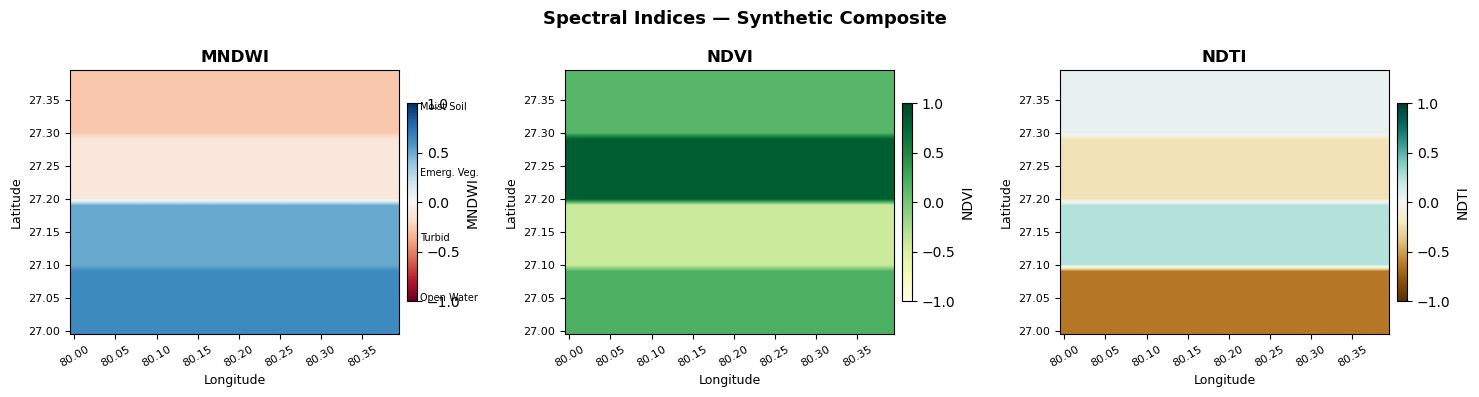

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (key, cmap) in zip(axes, [('MNDWI','RdBu'), ('NDVI','YlGn'), ('NDTI','BrBG')]):
    plot_index(indices[key], index_name=key, ax=ax, cmap=cmap)
    # Add zone labels on MNDWI panel
    if key == 'MNDWI':
        for label, y in [('Open Water', 27.05), ('Turbid', 27.14),
                          ('Emerg. Veg.', 27.24), ('Moist Soil', 27.34)]:
            ax.text(80.42, y, label, fontsize=7, va='center', color='k')
plt.suptitle('Spectral Indices — Synthetic Composite', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 3. Wetland Dynamics Classification
*(Singh & Sinha 2022, Remote Sensing Letters)*

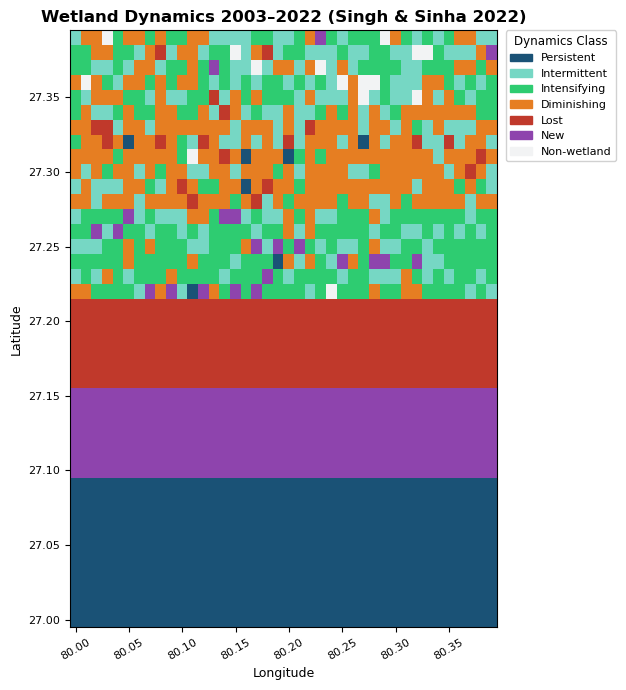

,Code,Class,Pixels,Area (%)
0,10,Persistent,401,25.1
1,6,Intermittent,180,11.2
2,5,Intensifying,236,14.8
3,4,Diminishing,241,15.1
4,3,Lost,260,16.2
5,2,New,261,16.3
6,0,Non-wetland,15,0.9


In [6]:
dynamics = classify_dynamics(mndwi_ts, nYear=3, thresholdWet=25, thresholdPersis=75)

# Static map
fig, ax = plot_dynamics(
    dynamics,
    title='Wetland Dynamics 2003–2022 (Singh & Sinha 2022)',
    legend_loc='outside right',
    savepath=os.path.join(OUTPUT_DIR, 'fig_dynamics_main.png'),
)
plt.show()
plt.show()

# Summary table
total = dynamics.size
pd.DataFrame([{'Code': c, 'Class': DYNAMICS_CLASSES[c],
               'Pixels': int((dynamics==c).sum()),
               'Area (%)': round(100*int((dynamics==c).sum())/total, 1)}
              for c in sorted(DYNAMICS_CLASSES.keys(), reverse=True)])

---
## 4. Temporal Aggregation

`aggregate_time()` reduces a multi-temporal stack to one composite per chosen
period before classification.  This is useful when:

- Your raw time series contains many scenes per year (e.g. every 16-day
  Landsat overpass) and you want annual/seasonal composites for dynamics.
- You want to classify WCT separately for each season.
- You fetched data with `fetch()` or `fetch_xee()` using `temporal_aggregation='all'`
  and now want to aggregate client-side.

| `freq` | Resampling | Result |
|--------|-----------|--------|
| `'annual'` | Year-end | One composite per calendar year |
| `'monthly'` | Month-end | One composite per calendar month |
| `'seasonal'` | Quarterly anchored to Dec | DJF / MAM / JJA / SON per year |
| `'all'` | None | Returns data unchanged |


In [7]:
from wetlandmapper import aggregate_time

# The synthetic mndwi_ts has 20 annual time steps.
# We can coarsen it further or demonstrate with a denser hypothetical series.
# For illustration: treat the existing annual stack as if it were monthly
# by re-labelling timestamps to monthly intervals.
import pandas as pd
import xarray as xr
import numpy as np

# Build a denser synthetic series: 10 years x 12 months
N_YRS, NY, NX = 10, 40, 40
monthly_dates = pd.date_range('2013-01-01', periods=N_YRS*12, freq='MS')
rng3 = np.random.default_rng(99)

# Base pattern from mndwi_ts + seasonal noise
season = np.sin(np.linspace(0, N_YRS*2*np.pi, N_YRS*12))[:, None, None] * 0.15
monthly_data = np.repeat(mndwi_data[:N_YRS], 12, axis=0) / 10  # thin time axis
monthly_data = np.clip(
    mndwi_ts.values[:N_YRS].repeat(12, axis=0) + season + rng3.normal(0, 0.03, (N_YRS*12, NY, NX)),
    -1, 1
)

mndwi_monthly = xr.DataArray(
    monthly_data,
    dims=['time','y','x'],
    coords={'time': monthly_dates,
             'y': np.linspace(27.0, 27.39, NY),
             'x': np.linspace(80.0, 80.39, NX)},
    name='MNDWI'
)
print(f'Dense monthly stack: {mndwi_monthly.sizes}')

Dense monthly stack: Frozen({'time': 120, 'y': 40, 'x': 40})


In [8]:
# Aggregate to each temporal frequency
mndwi_annual   = aggregate_time(mndwi_monthly, freq='annual',   method='median')
mndwi_seasonal = aggregate_time(mndwi_monthly, freq='seasonal',  method='median')
mndwi_monthagg = aggregate_time(mndwi_monthly, freq='monthly',   method='median')

print(f'Raw monthly  : {mndwi_monthly.sizes["time"]:3d} time steps')
print(f'Monthly agg  : {mndwi_monthagg.sizes["time"]:3d} time steps (should equal raw here)')
print(f'Seasonal agg : {mndwi_seasonal.sizes["time"]:3d} time steps  ({N_YRS} years × 4 seasons)')
print(f'Annual agg   : {mndwi_annual.sizes["time"]:3d} time steps  ({N_YRS} years)')

Raw monthly  : 120 time steps
Monthly agg  : 120 time steps (should equal raw here)
Seasonal agg :  41 time steps  (10 years × 4 seasons)
Annual agg   :  10 time steps  (10 years)


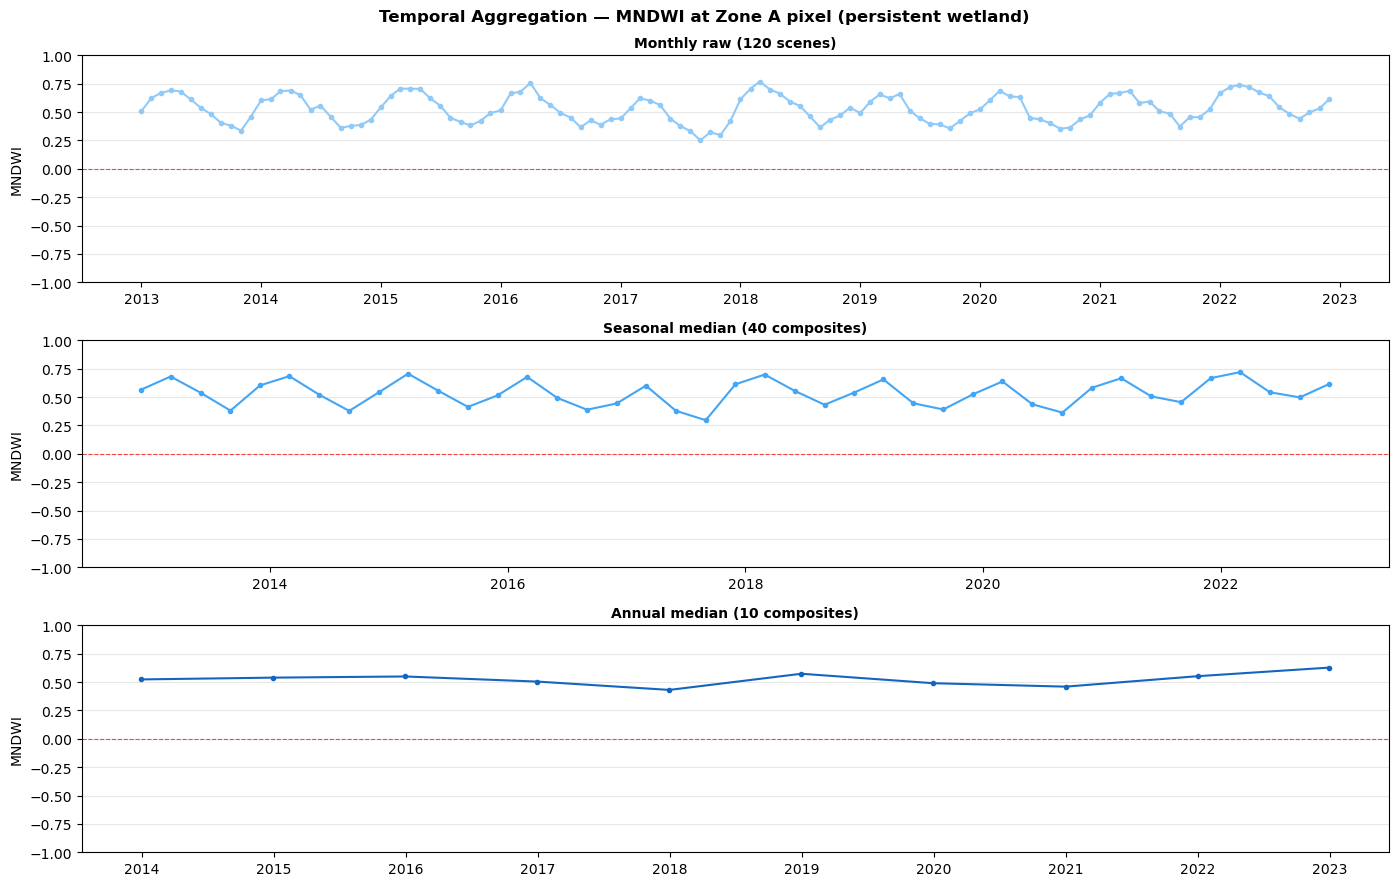

In [9]:
# ── Compare MNDWI at a persistent-zone pixel across aggregation levels ──────
px_y, px_x = 27.05, 80.20   # Zone A — always wet

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)
for ax, da, label, color in zip(
    axes,
    [mndwi_monthly, mndwi_seasonal, mndwi_annual],
    ['Monthly raw (120 scenes)', 'Seasonal median (40 composites)', 'Annual median (10 composites)'],
    ['#90caf9', '#42a5f5', '#1565c0'],
):
    ts = da.sel(y=px_y, x=px_x, method='nearest').to_pandas()
    ax.plot(ts.index, ts.values, color=color, linewidth=1.5, marker='o', markersize=3)
    ax.axhline(0, color='red', linewidth=0.8, linestyle='--', alpha=0.7)
    ax.set_ylim(-1, 1)
    ax.set_ylabel('MNDWI', fontsize=10)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Temporal Aggregation — MNDWI at Zone A pixel (persistent wetland)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

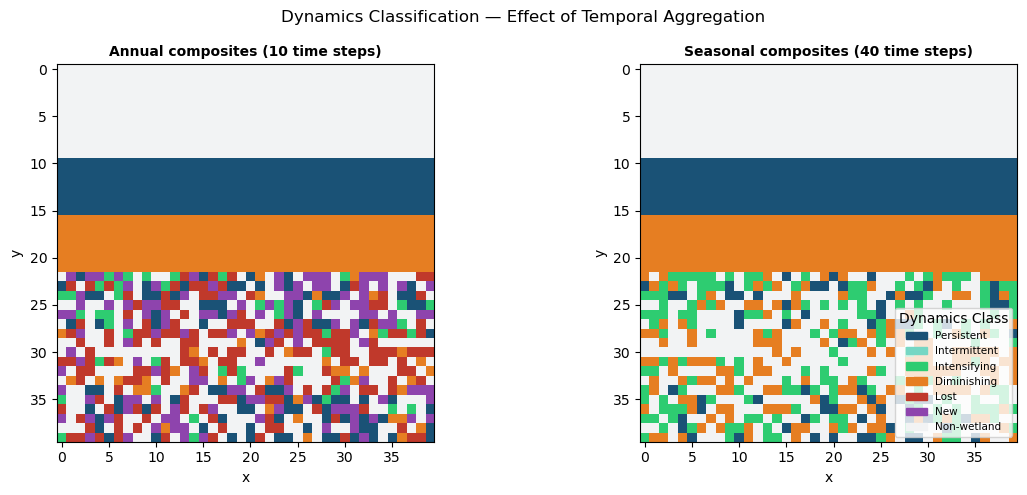

In [10]:
# ── Dynamics classification from different aggregation levels ────────────────
# Use the 20-year annual stack (mndwi_ts) as baseline;
# compare with seasonal and monthly aggregated versions of the denser stack

dyn_annual   = classify_dynamics(mndwi_annual,   nYear=2, thresholdWet=25, thresholdPersis=75)
dyn_seasonal = classify_dynamics(mndwi_seasonal, nYear=4, thresholdWet=25, thresholdPersis=75)

codes_d  = sorted(DYNAMICS_CLASSES.keys(), reverse=True)
cmap_d   = mcolors.ListedColormap([DYNAMICS_COLORS[c] for c in codes_d])
bounds_d = sorted([c - 0.5 for c in codes_d] + [min(codes_d) + 0.5])
norm_d   = mcolors.BoundaryNorm(bounds_d, cmap_d.N)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, dyn, label in zip(
    axes,
    [dyn_annual, dyn_seasonal],
    ['Annual composites (10 time steps)', 'Seasonal composites (40 time steps)']
):
    ax.imshow(dyn.values, cmap=cmap_d, norm=norm_d, origin='upper', interpolation='nearest')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('y')

patches = [mpatches.Patch(color=DYNAMICS_COLORS[c], label=DYNAMICS_CLASSES[c]) for c in codes_d]
axes[1].legend(handles=patches, loc='lower right', fontsize=7.5, title='Dynamics Class')
plt.suptitle('Dynamics Classification — Effect of Temporal Aggregation', fontsize=12)
plt.tight_layout()
plt.show()

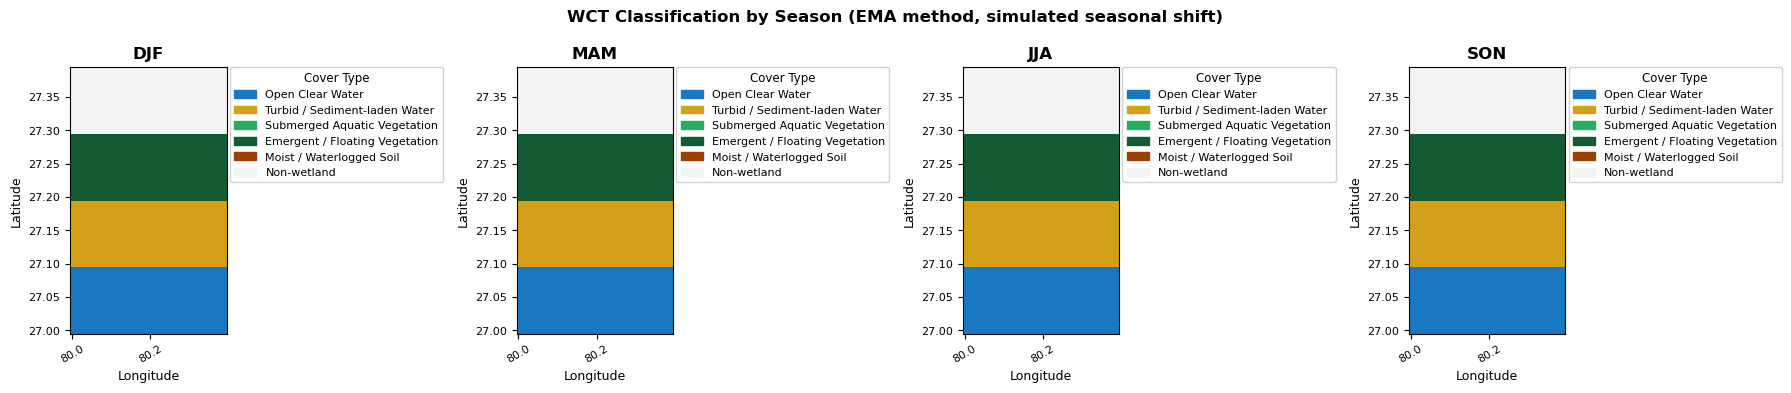

In [12]:
# ── WCT classification for each season ──────────────────────────────────────
# Aggregate the single composite to seasonal (just to illustrate the API;
# real usage would use fetch() with temporal_aggregation='seasonal')

# Build a mock multi-index seasonal Dataset by tiling the composite
# with slight per-season perturbations
season_labels = ['DJF','MAM','JJA','SON']
perturbations = {'DJF': 0.05, 'MAM': 0.0, 'JJA': -0.08, 'SON': 0.03}  # MNDWI shift

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, season_name in zip(axes, season_labels):
    # Perturb MNDWI to simulate seasonal variation
    perturbed_indices = indices.copy()
    perturbed_indices['MNDWI'] = (indices['MNDWI'] + perturbations[season_name]).clip(-1, 1)
    wct_season = classify_wct_ema(perturbed_indices)
    plot_wct(wct_season.wetland_cover_type, ax=ax, title=season_name)

plt.suptitle('WCT Classification by Season (EMA method, simulated seasonal shift)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. WCT: Original EMA Combination-Code Method
*(Singh et al. 2022, Environmental Monitoring and Assessment)*

### How it works

Each index's positive [0, 1] range is independently divided into **four equal bins** of width 0.25:

| Level | Range | Name |
|-------|-------|------|
| 0 | < 0.00 | Negative / dry |
| 1 | [0.00, 0.25) | Low |
| 2 | [0.25, 0.50) | Moderate-Low |
| 3 | [0.50, 0.75) | Moderate-High |
| 4 | [0.75, 1.00] | High |

Every pixel then carries a **three-way combination code** — one level per index, e.g. `w2v3t1` 
(moderate MNDWI, high NDVI, low NDTI).  The WCT class is read from a **5×5×5 lookup table** 
indexed by `(mndwi_level, ndvi_level, ndti_level)`.  There is no priority ordering; each 
unique three-way combination has exactly one class.

**Critical case — vegetation-masked pixels:** A pixel with *negative* MNDWI (level 0 — water 
not visible) but *high* NDVI (level 3 or 4) is classified as **WCT 4 (Emergent/Floating Veg.)** 
because dense aquatic vegetation completely attenuates the water signal in MNDWI. The code 
`w0v4t0` unambiguously points to an aquatic vegetated patch even though MNDWI alone looks dry. However, it is only valid if there are no terrestrial pixels, i.e., the xarray stack or the AOI for GEE representes wetlands only.

| WCT | MNDWI levels | NDVI levels | NDTI levels | Cover type |
|-----|-------------|------------|------------|------------|
| 1 | w3–w4 | v0–v1 | t0–t1 | Open Clear Water |
| 2 | w2–w4 | v0–v1 | t2–t4 | Turbid / Sediment Water |
| 3 | w2–w4 | v1–v2 | t0–t1 | Submerged Aquatic Veg. |
| **4** | **w0–w4** | **v3–v4** | **t0–t1** | **Emergent / Floating Veg. (any MNDWI!)** |
| 5 | w1 | v0–v1 | t0–t2 | Moist / Waterlogged Soil |

In [13]:
from wetlandmapper.wct import build_ema_lookup_table

wct_ema_ds = classify_wct_ema(indices)   # returns Dataset: wetland_cover_type + combination_code

wct_ema   = wct_ema_ds['wetland_cover_type']   # int8 class map
combo_map = wct_ema_ds['combination_code']     # int16 index-level fingerprint

print('Classification method:', wct_ema.attrs['classification_method'])
print('Quartile step (bin width):', wct_ema.attrs['step'])
print('Bin boundaries:', wct_ema.attrs['boundaries'])

# Pixel summary
total = wct_ema.size
pd.DataFrame([{'Code': c, 'Cover Type': WCT_CLASSES[c],
               'Pixels': int((wct_ema == c).sum()),
               'Area (%)': round(100 * int((wct_ema == c).sum()) / total, 1)}
              for c in sorted(WCT_CLASSES.keys())])

Classification method: EMA-combination-lookup
Quartile step (bin width): 0.25
Bin boundaries: [0.0, 0.25, 0.5, 0.75, 1.0]


,Code,Cover Type,Pixels,Area (%)
0,0,Non-wetland,400,25.0
1,1,Open Clear Water,400,25.0
2,2,Turbid / Sediment-laden Water,400,25.0
3,3,Submerged Aquatic Vegetation,0,0.0
4,4,Emergent / Floating Vegetation,400,25.0
5,5,Moist / Waterlogged Soil,0,0.0


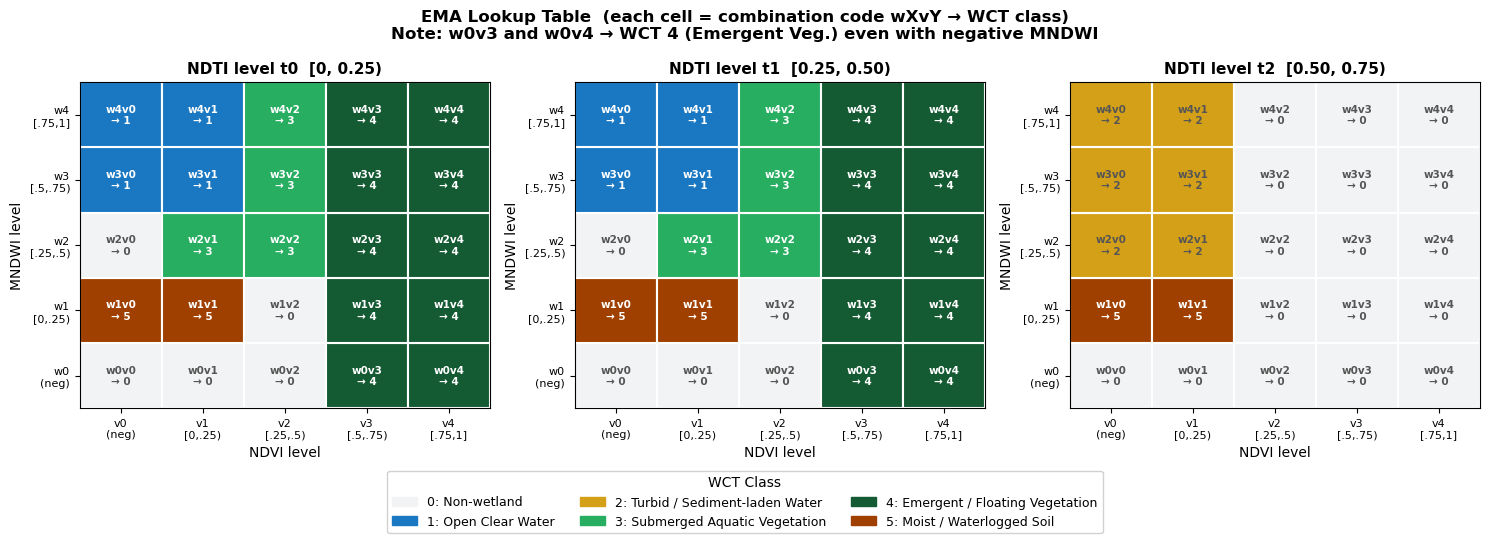

In [14]:
# ─── Lookup table: 5×5 slices for NDTI = 0, 1, 2 ──────────────────────────
table = build_ema_lookup_table(n_parts=4)

# Map class code → colour for the heatmap
class_color_arr = np.array(['#f2f3f4','#1a78c2','#d4a017','#27ae60','#145a32','#a04000'])
class_names_arr = ['Non-wetland','Open Clear Water','Turbid Water',
                    'Submerged Veg.','Emergent Veg.','Moist Soil']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ndti_slices = [0, 1, 2]

for ax, t_slice in zip(axes, ndti_slices):
    # Draw coloured cells for this NDTI level
    slice_2d = table[:, :, t_slice]   # shape (5,5): MNDWI × NDVI
    img = np.array([[class_color_arr[v] for v in row] for row in slice_2d])

    for w in range(5):
        for v in range(5):
            cls = int(slice_2d[w, v])
            # Cell background
            rect = plt.Rectangle([v-0.5, w-0.5], 1, 1,
                                  facecolor=class_color_arr[cls],
                                  edgecolor='white', linewidth=1.5)
            ax.add_patch(rect)
            # Combination code label
            text_color = 'white' if cls in [1,3,4,5] else '#555'
            ax.text(v, w, f'w{w}v{v}\n→ {cls}',
                    ha='center', va='center', fontsize=7.5,
                    color=text_color, fontweight='bold')

    ax.set_xlim(-0.5, 4.5); ax.set_ylim(-0.5, 4.5)
    ax.set_xticks(range(5))
    ax.set_xticklabels(['v0\n(neg)','v1\n[0,.25)','v2\n[.25,.5)','v3\n[.5,.75)','v4\n[.75,1]'], fontsize=8)
    ax.set_yticks(range(5))
    ax.set_yticklabels(['w0\n(neg)','w1\n[0,.25)','w2\n[.25,.5)','w3\n[.5,.75)','w4\n[.75,1]'], fontsize=8)
    ax.set_xlabel('NDVI level', fontsize=10)
    ax.set_ylabel('MNDWI level', fontsize=10)
    ndti_label = ['[0, 0.25)','[0.25, 0.50)','[0.50, 0.75)'][t_slice]
    ax.set_title(f'NDTI level t{t_slice}  {ndti_label}', fontsize=11, fontweight='bold')

# Legend
patches = [mpatches.Patch(color=WCT_COLORS[c], label=f'{c}: {WCT_CLASSES[c]}')
           for c in sorted(WCT_CLASSES.keys())]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=9,
           title='WCT Class', framealpha=0.9, bbox_to_anchor=(0.5, -0.08))

plt.suptitle(
    'EMA Lookup Table  (each cell = combination code wXvY → WCT class)\n'
    'Note: w0v3 and w0v4 → WCT 4 (Emergent Veg.) even with negative MNDWI',
    fontsize=12, fontweight='bold'
)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

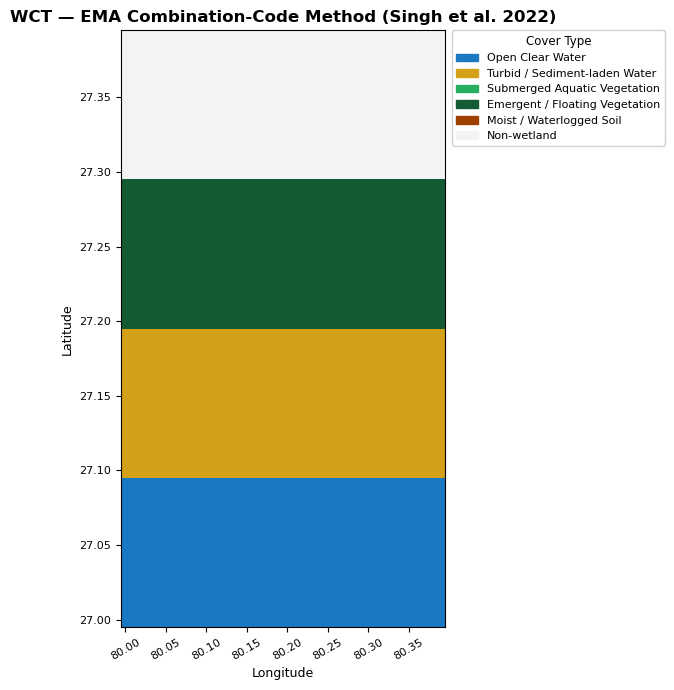

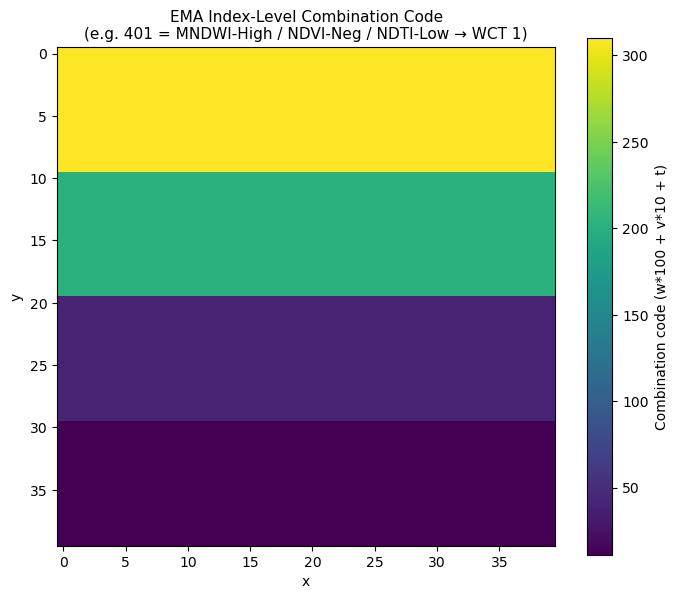

Unique combination codes present: [11, 40, 202, 310]


In [15]:
fig, ax = plot_wct(
    wct_ema,
    title='WCT — EMA Combination-Code Method (Singh et al. 2022)',
    legend_loc='outside right',
    savepath=os.path.join(OUTPUT_DIR, 'fig_wct_ema_main.png'),
)
plt.show()

# ── Combination-code map ────────────────────────────────────────────────────
# Each pixel encodes which index-level triplet drove its WCT class.
# Hundreds = MNDWI level, tens = NDVI level, units = NDTI level.
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(combo_map.values, cmap='viridis', origin='upper', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Combination code (w*100 + v*10 + t)')
ax.set_title('EMA Index-Level Combination Code\n'
             '(e.g. 401 = MNDWI-High / NDVI-Neg / NDTI-Low → WCT 1)', fontsize=11)
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout(); plt.show()
print('Unique combination codes present:', sorted(set(int(v) for v in combo_map.values.flatten())))

In [16]:
# ─── Demonstrate the vegetation-masking case ────────────────────────────────
# Create a synthetic pixel with negative MNDWI but high NDVI
# (dense aquatic vegetation completely masks the water signal in MNDWI)

veg_cases = pd.DataFrame([
    {'Scenario': 'Open clear water',
     'MNDWI': 0.65, 'NDVI': 0.05, 'NDTI': 0.02,
     'w level': 3, 'v level': 1, 'NDTI level': 1, 'code': 'w3v1t1', 'Expected': 'WCT 1'},
    {'Scenario': 'Turbid sediment water',
     'MNDWI': 0.40, 'NDVI': 0.08, 'NDTI': 0.35,
     'w level': 2, 'v level': 1, 'NDTI level': 2, 'code': 'w2v1t2', 'Expected': 'WCT 2'},
    {'Scenario': 'Submerged aquatic veg',
     'MNDWI': 0.35, 'NDVI': 0.30, 'NDTI': 0.05,
     'w level': 2, 'v level': 2, 'NDTI level': 1, 'code': 'w2v2t1', 'Expected': 'WCT 3'},
    {'Scenario': 'Emergent veg — water visible',
     'MNDWI': 0.15, 'NDVI': 0.60, 'NDTI': 0.01,
     'w level': 1, 'v level': 3, 'NDTI level': 1, 'code': 'w1v3t1', 'Expected': 'WCT 4'},
    {'Scenario': '** Emergent veg — water MASKED by canopy **',
     'MNDWI': -0.15, 'NDVI': 0.78, 'NDTI': 0.05,
     'w level': 0, 'v level': 4, 'NDTI level': 1, 'code': 'w0v4t1', 'Expected': 'WCT 4'},
    {'Scenario': '** Emergent veg — water MASKED, MNDWI=-0.30 **',
     'MNDWI': -0.30, 'NDVI': 0.55, 'NDTI': 0.10,
     'w level': 0, 'v level': 3, 'NDTI level': 1, 'code': 'w0v3t1', 'Expected': 'WCT 4'},
    {'Scenario': 'Moist / waterlogged soil',
     'MNDWI': 0.12, 'NDVI': 0.10, 'NDTI': 0.20,
     'w level': 1, 'v level': 1, 'NDTI level': 1, 'code': 'w1v1t1', 'Expected': 'WCT 5'},
    {'Scenario': 'Dry upland (non-wetland)',
     'MNDWI': -0.40, 'NDVI': 0.15, 'NDTI': 0.05,
     'w level': 0, 'v level': 1, 'NDTI level': 1, 'code': 'w0v1t1', 'Expected': 'WCT 0'},
])

# Compute actual class using lookup table
from wetlandmapper.wct import build_ema_lookup_table
tbl = build_ema_lookup_table()
veg_cases['Classified as'] = [
    f"WCT {tbl[r['w level'], r['v level'], r['NDTI level']]} — "
    f"{WCT_CLASSES[int(tbl[r['w level'], r['v level'], r['NDTI level']])]}"
    for _, r in veg_cases.iterrows()
]

print('Combination-code lookup — including vegetation-masked pixels:')
print()
veg_cases[['Scenario','code','MNDWI','NDVI','NDTI','Expected','Classified as']]

Combination-code lookup — including vegetation-masked pixels:



,Scenario,code,MNDWI,NDVI,NDTI,Expected,Classified as
0,Open clear water,w3v1t1,0.65,0.05,0.02,WCT 1,WCT 1 — Open Clear Water
1,Turbid sediment water,w2v1t2,0.40,0.08,0.35,WCT 2,WCT 2 — Turbid / Sediment-laden Water
2,Submerged aquatic veg,w2v2t1,0.35,0.30,0.05,WCT 3,WCT 3 — Submerged Aquatic Vegetation
3,Emergent veg — water visible,w1v3t1,0.15,0.60,0.01,WCT 4,WCT 4 — Emergent / Floating Vegetation
4,** Emergent veg — water MASKED by canopy **,w0v4t1,-0.15,0.78,0.05,WCT 4,WCT 4 — Emergent / Floating Vegetation
5,"** Emergent veg — water MASKED, MNDWI=-0.30 **",w0v3t1,-0.30,0.55,0.10,WCT 4,WCT 4 — Emergent / Floating Vegetation
6,Moist / waterlogged soil,w1v1t1,0.12,0.10,0.20,WCT 5,WCT 5 — Moist / Waterlogged Soil
7,Dry upland (non-wetland),w0v1t1,-0.40,0.15,0.05,WCT 0,WCT 0 — Non-wetland


---
## 6. WCT: Improved Threshold Method

Same five classes, but boundaries are continuous floating-point values —
not locked to multiples of 0.25.  This enables sub-quartile calibration
for different sensors or seasons.

In [17]:
wct_thr = classify_wct(indices)  # default thresholds from Singh et al. 2022

print('Classification method:', wct_thr.attrs['classification_method'])
print('Thresholds:', wct_thr.attrs['thresholds'])

total = wct_thr.size
pd.DataFrame([{'Code': c, 'Cover Type': WCT_CLASSES[c],
               'Pixels': int((wct_thr==c).sum()),
               'Area (%)': round(100*int((wct_thr==c).sum())/total, 1)}
              for c in sorted(WCT_CLASSES.keys())])

Classification method: threshold
Thresholds: {'mndwi_water': 0.0, 'mndwi_moist': -0.2, 'ndvi_veg_high': 0.2, 'ndvi_veg_low': 0.05, 'ndti_turbid': 0.0}


,Code,Cover Type,Pixels,Area (%)
0,0,Non-wetland,400,25.0
1,1,Open Clear Water,0,0.0
2,2,Turbid / Sediment-laden Water,400,25.0
3,3,Submerged Aquatic Vegetation,400,25.0
4,4,Emergent / Floating Vegetation,400,25.0
5,5,Moist / Waterlogged Soil,0,0.0


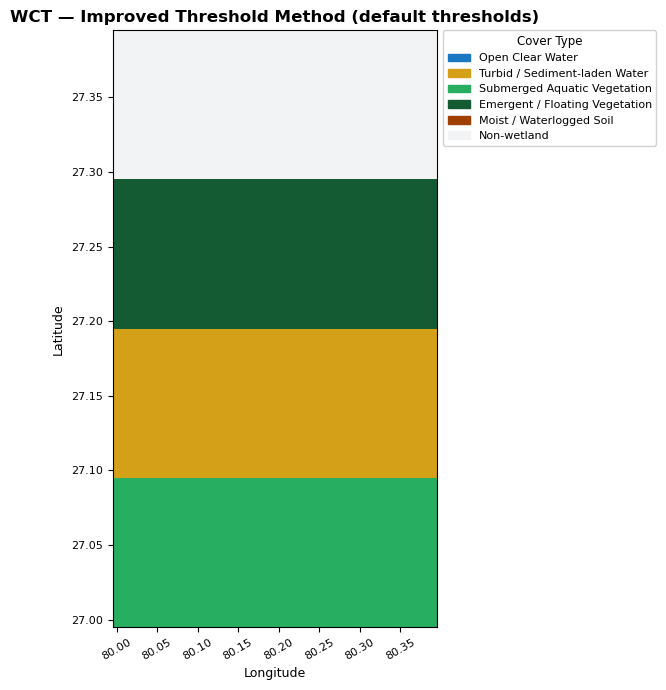

In [18]:
fig, ax = plot_wct(
    wct_thr,
    title='WCT — Improved Threshold Method (default thresholds)',
    legend_loc='outside right',
    savepath=os.path.join(OUTPUT_DIR, 'fig_wct_threshold_main.png'),
)
plt.show()


---
## 7. EMA vs Improved — Comparison

### 7a. Side-by-side maps

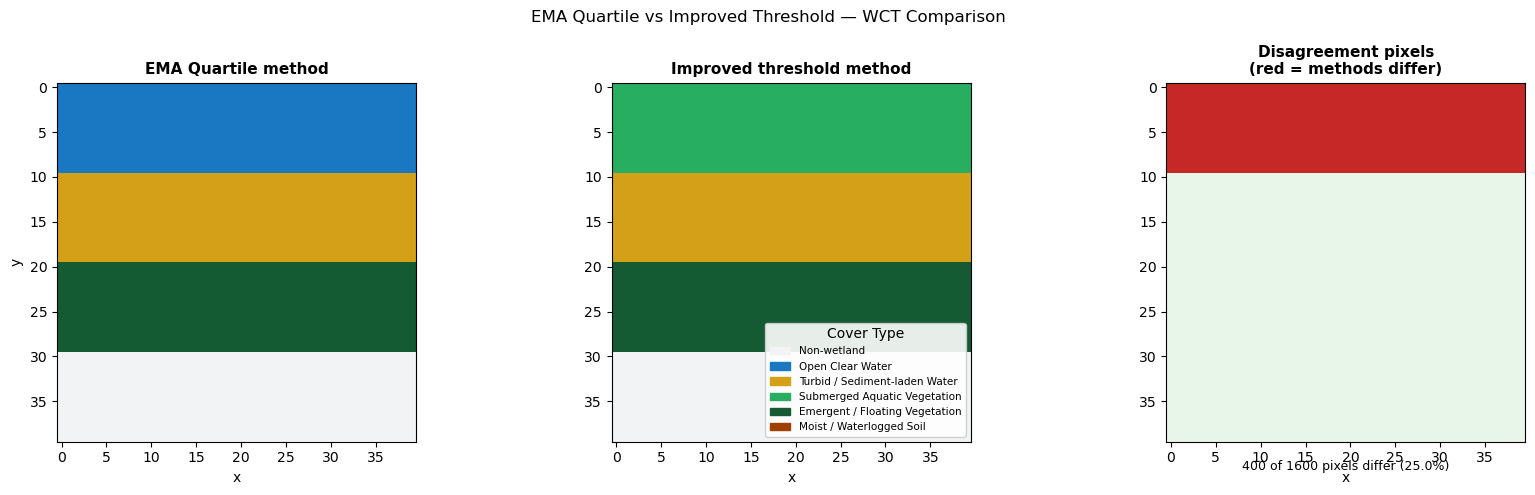

In [19]:
wct_codes  = sorted(WCT_CLASSES.keys())
wct_colors = [WCT_COLORS[c] for c in wct_codes]
cmap_wct   = mcolors.ListedColormap(wct_colors)
bounds_wct = [c - 0.5 for c in wct_codes] + [wct_codes[-1] + 0.5]
norm_wct   = mcolors.BoundaryNorm(sorted(bounds_wct), cmap_wct.N)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# EMA map
axes[0].imshow(wct_ema.values, cmap=cmap_wct, norm=norm_wct,
               origin='upper', interpolation='nearest')
axes[0].set_title('EMA Quartile method', fontsize=11, fontweight='bold')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

# Improved map
axes[1].imshow(wct_thr.values, cmap=cmap_wct, norm=norm_wct,
               origin='upper', interpolation='nearest')
axes[1].set_title('Improved threshold method', fontsize=11, fontweight='bold')
axes[1].set_xlabel('x')

# Difference map (pixels that differ between the two methods)
diff = (wct_ema.values != wct_thr.values).astype(int)
diff_cmap = mcolors.ListedColormap(['#e8f5e9', '#c62828'])
axes[2].imshow(diff, cmap=diff_cmap, origin='upper', interpolation='nearest', vmin=0, vmax=1)
axes[2].set_title('Disagreement pixels\n(red = methods differ)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('x')
n_diff = int(diff.sum())
axes[2].text(0.5, -0.08, f'{n_diff} of {diff.size} pixels differ ({100*n_diff/diff.size:.1f}%)',
             transform=axes[2].transAxes, ha='center', fontsize=9)

patches = [mpatches.Patch(color=WCT_COLORS[c], label=WCT_CLASSES[c]) for c in wct_codes]
axes[1].legend(handles=patches, loc='lower right', fontsize=7.5,
               title='Cover Type', framealpha=0.9)
plt.suptitle('EMA Quartile vs Improved Threshold — WCT Comparison', fontsize=12)
plt.tight_layout(); plt.show()

### 7b. Pixel-level class comparison table

In [20]:
comp = pd.DataFrame({
    'EMA class':      [WCT_CLASSES[int(c)] for c in wct_ema.values.flatten()],
    'Improved class': [WCT_CLASSES[int(c)] for c in wct_thr.values.flatten()],
})
ct = pd.crosstab(comp['EMA class'], comp['Improved class'],
                 rownames=['EMA'], colnames=['Improved'])
ct

Improved,Emergent / Floating Vegetation,Non-wetland,Submerged Aquatic Vegetation,Turbid / Sediment-laden Water
EMA,,,,
Emergent / Floating Vegetation,400,0,0,0
Non-wetland,0,400,0,0
Open Clear Water,0,0,400,0
Turbid / Sediment-laden Water,0,0,0,400


### 7c. Effect of n_parts (EMA sensitivity)

Changing `n_parts` changes the bin width — coarser (fewer parts) or finer (more parts).

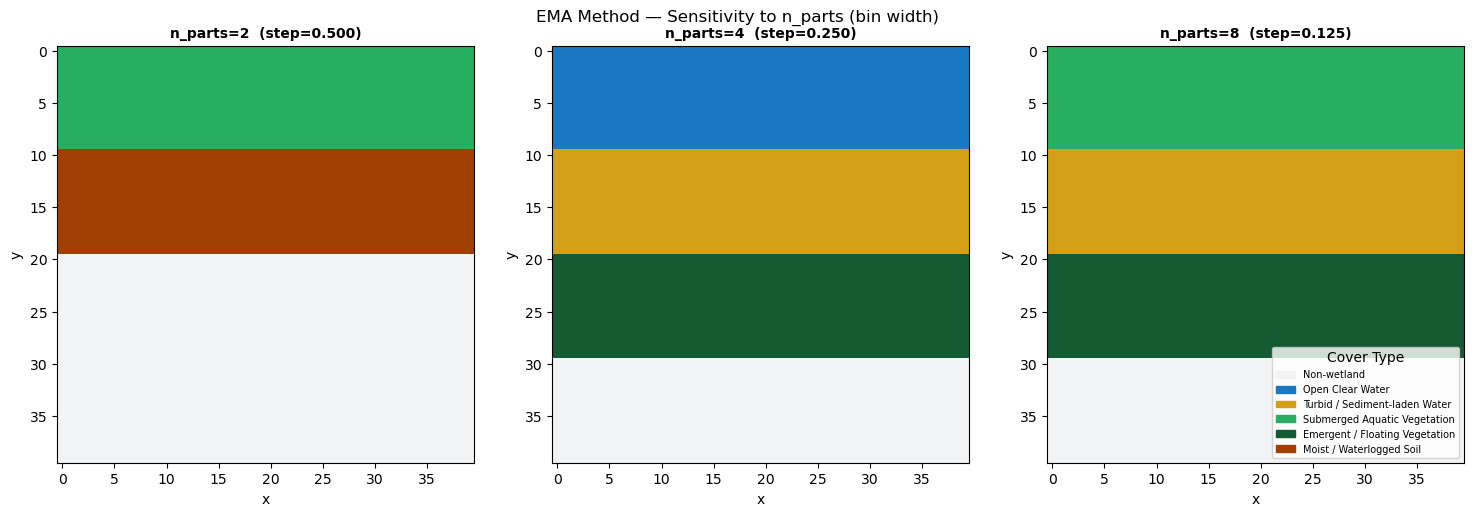

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, np_ in zip(axes, [2, 4, 8]):
    wct_np = classify_wct_ema(indices, n_parts=np_)['wetland_cover_type']
    ax.imshow(wct_np.values, cmap=cmap_wct, norm=norm_wct,
              origin='upper', interpolation='nearest')
    ax.set_title(f'n_parts={np_}  (step={1/np_:.3f})', fontsize=10, fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('y')

patches = [mpatches.Patch(color=WCT_COLORS[c], label=WCT_CLASSES[c]) for c in wct_codes]
axes[2].legend(handles=patches, loc='lower right', fontsize=7, title='Cover Type')
plt.suptitle('EMA Method — Sensitivity to n_parts (bin width)', fontsize=12)
plt.tight_layout(); plt.show()

---
## 8. Chilika Lake WCT Time Series

Chilika is India's largest brackish-water lagoon (Odisha) and a Ramsar site used as
a validation area in Singh et al. (2022).  The synthetic time series below mimics
the expected seasonal cycle of Chilika's WCT composition across 12 months,
showing how open water, turbid water, aquatic vegetation, and moist soil shift
through the monsoon and post-monsoon seasons.

> **Note:** This is synthetic demonstration data modelled on the known phenology
> of Chilika.  Use `wetlandmapper.gee.fetch()` with the Chilika bounding box
> (Section 9) to reproduce with real Landsat/Sentinel-2 imagery.

In [22]:
# ─── Synthetic Chilika WCT seasonal composition ───────────────────────────
# 5 years × 12 months (each column = one month of year)
# Values are % of wetland pixels in each WCT class
N_YEARS_CH = 5
months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']
rng2 = np.random.default_rng(7)

def seasonal_chilika(seed_noise=0.04):
    """Generate synthetic but physically plausible WCT fractions."""
    # Base seasonal cycle per class (12 months)
    # Chilika: max water in Sep-Oct (post-monsoon), vegetation peak Nov-Jan
    open_water = np.array([32,30,27,24,20,15,22,30,40,38,36,34], dtype=float)
    turbid     = np.array([10,10, 9, 8, 7,12,18,22,18,14,11,11], dtype=float)
    subm_veg   = np.array([ 5, 5, 5, 4, 4, 3, 2, 2, 3, 5, 6, 6], dtype=float)
    emerg_veg  = np.array([18,20,22,24,22,18,12, 8, 8,12,15,17], dtype=float)
    moist_soil = np.array([10, 9, 8, 8,10,14,16,12, 8, 8, 9,10], dtype=float)
    # Non-wetland = remainder
    non_wet    = 100 - (open_water+turbid+subm_veg+emerg_veg+moist_soil)
    base = np.stack([open_water,turbid,subm_veg,emerg_veg,moist_soil,non_wet])
    return base

base = seasonal_chilika()

# Stack 5 annual cycles with small inter-annual variability
all_rows = []
for yr in range(N_YEARS_CH):
    noise = rng2.normal(0, 1.5, base.shape)
    noisy = np.clip(base + noise, 0, None)
    # Renormalise to 100%
    noisy = noisy / noisy.sum(axis=0) * 100
    for m in range(12):
        all_rows.append({
            'Year': 2018 + yr,
            'Month': months[m],
            'Date': pd.Timestamp(2018+yr, m+1, 15),
            'Open Clear Water':          round(noisy[0,m], 1),
            'Turbid Water':              round(noisy[1,m], 1),
            'Submerged Aquatic Veg.':    round(noisy[2,m], 1),
            'Emergent / Floating Veg.':  round(noisy[3,m], 1),
            'Moist / Waterlogged Soil':  round(noisy[4,m], 1),
            'Non-wetland':               round(noisy[5,m], 1),
        })

chilika_df = pd.DataFrame(all_rows).set_index('Date').sort_index()

wct_cols = [
    'Open Clear Water', 'Turbid Water', 'Submerged Aquatic Veg.',
    'Emergent / Floating Veg.', 'Moist / Waterlogged Soil', 'Non-wetland'
]
wct_palette = ['#1a78c2','#d4a017','#27ae60','#145a32','#a04000','#f2f3f4']

print(chilika_df[wct_cols].head(6))

            Open Clear Water  Turbid Water  Submerged Aquatic Veg.  \
Date                                                                 
2018-01-15              32.1          10.2                     5.3   
2018-02-15              29.7           8.4                     4.6   
2018-03-15              27.6           9.3                     1.3   
2018-04-15              23.8           9.5                     3.4   
2018-05-15              20.0           5.2                     4.1   
2018-06-15              13.7          11.5                     3.2   

            Emergent / Floating Veg.  Moist / Waterlogged Soil  Non-wetland  
Date                                                                         
2018-01-15                      18.0                       9.1         25.4  
2018-02-15                      20.8                      11.7         24.7  
2018-03-15                      22.0                       9.5         30.3  
2018-04-15                      25.0             

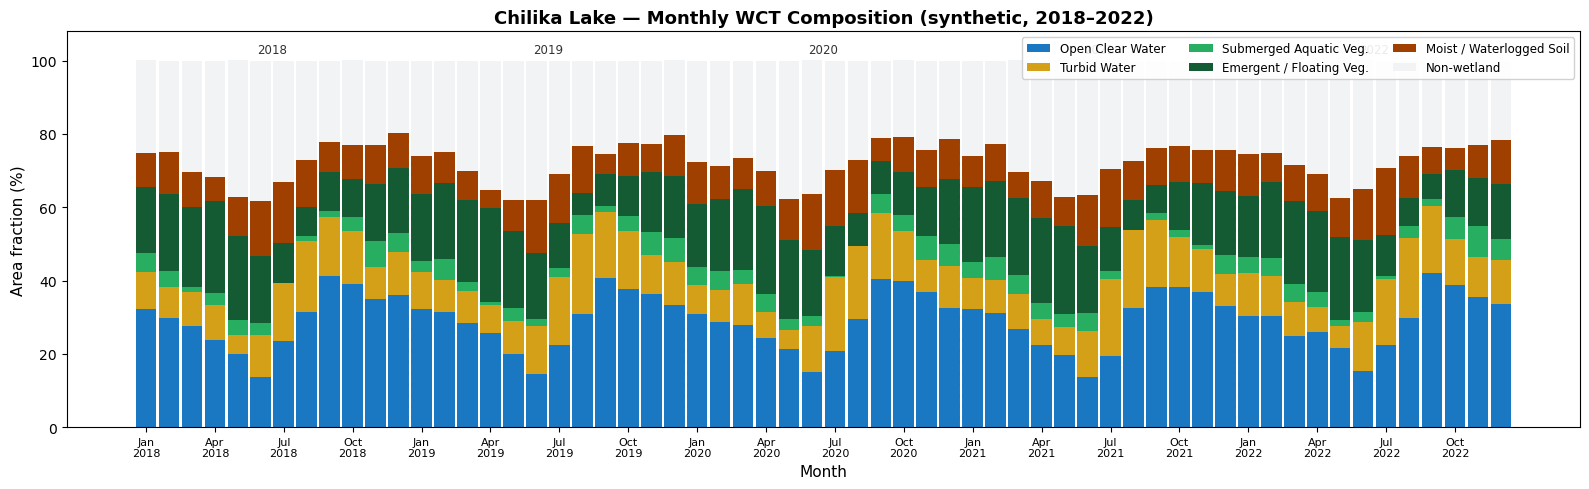

In [23]:
# ─── Stacked bar chart — full time series ─────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

x = np.arange(len(chilika_df))
bottom = np.zeros(len(chilika_df))
for col, color in zip(wct_cols, wct_palette):
    vals = chilika_df[col].values
    ax.bar(x, vals, bottom=bottom, color=color, label=col, width=0.9, edgecolor='none')
    bottom += vals

# Month tick labels
ax.set_xticks(x[::3])
ax.set_xticklabels(
    [f"{r['Month']}\n{r['Year']}" for _, r in chilika_df.reset_index().iloc[::3].iterrows()],
    fontsize=8
)

# Year separator lines
for yr in range(1, N_YEARS_CH):
    ax.axvline(yr * 12 - 0.5, color='white', linewidth=1.5, linestyle='--', alpha=0.8)
    ax.text(yr * 12 + 5.5, 102, f'{2018+yr}', ha='center', fontsize=8.5, color='#333')
ax.text(5.5, 102, '2018', ha='center', fontsize=8.5, color='#333')

ax.set_ylim(0, 108)
ax.set_ylabel('Area fraction (%)', fontsize=11)
ax.set_xlabel('Month', fontsize=11)
ax.set_title('Chilika Lake — Monthly WCT Composition (synthetic, 2018–2022)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=8.5, ncol=3, framealpha=0.9)
plt.tight_layout()
plt.show()

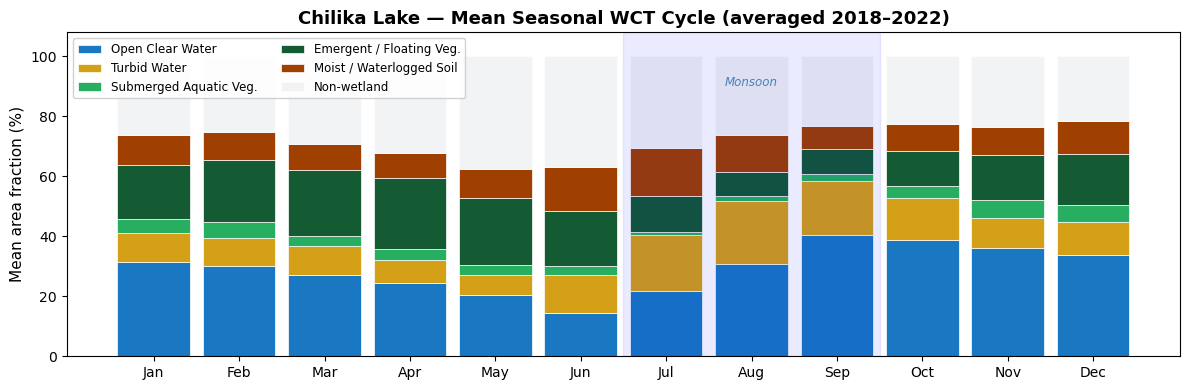

In [24]:
# ─── Mean seasonal cycle (averaged across 5 years) ────────────────────────
monthly_mean = chilika_df[wct_cols + ['Month']].copy()
monthly_mean['Month'] = [r.month for r in chilika_df.index]
seasonal = monthly_mean.groupby('Month').mean()
seasonal.index = months

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(12)
bottom = np.zeros(12)
for col, color in zip(wct_cols, wct_palette):
    ax.bar(x, seasonal[col].values, bottom=bottom, color=color, label=col,
           width=0.85, edgecolor='white', linewidth=0.5)
    bottom += seasonal[col].values

ax.set_xticks(x); ax.set_xticklabels(months, fontsize=10)
ax.set_ylim(0, 108)
ax.set_ylabel('Mean area fraction (%)', fontsize=11)
ax.set_title('Chilika Lake — Mean Seasonal WCT Cycle (averaged 2018–2022)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=8.5, ncol=2, framealpha=0.9)

# Annotate monsoon season
ax.axvspan(5.5, 8.5, alpha=0.08, color='blue')
ax.text(7, 90, 'Monsoon', ha='center', fontsize=8.5, color='steelblue', style='italic')
plt.tight_layout()
plt.show()

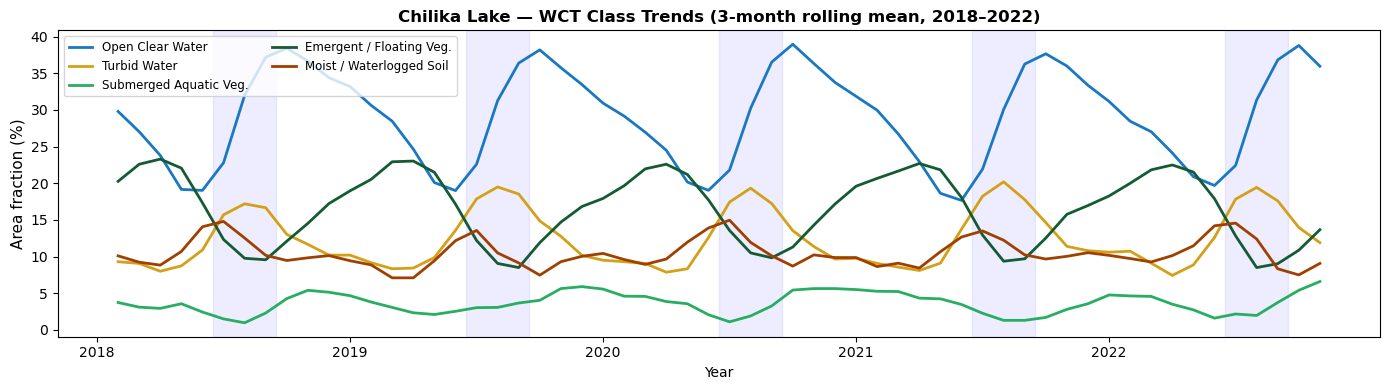

In [25]:
# ─── Line chart: wetland classes only (excluding Non-wetland) ─────────────
fig, ax = plt.subplots(figsize=(14, 4))
wetland_cols = wct_cols[:-1]  # drop 'Non-wetland'
wetland_colors = wct_palette[:-1]

# Annual mean per class
annual = chilika_df[wetland_cols].resample('YE').mean()
annual.index = [2018, 2019, 2020, 2021, 2022]

for col, color in zip(wetland_cols, wetland_colors):
    monthly_smooth = chilika_df[col].rolling(3, center=True).mean()
    ax.plot(range(len(chilika_df)), monthly_smooth.values,
            color=color, linewidth=2, label=col)

ax.set_xticks(np.arange(0, len(chilika_df), 12))
ax.set_xticklabels([2018,2019,2020,2021,2022])
ax.set_ylabel('Area fraction (%)', fontsize=11)
ax.set_xlabel('Year')
ax.set_title('Chilika Lake — WCT Class Trends (3-month rolling mean, 2018–2022)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8.5, ncol=2)
ax.axvspan(5.5, 8.5, alpha=0.07, color='blue')
ax.axvspan(17.5, 20.5, alpha=0.07, color='blue')
ax.axvspan(29.5, 32.5, alpha=0.07, color='blue')
ax.axvspan(41.5, 44.5, alpha=0.07, color='blue')
ax.axvspan(53.5, 56.5, alpha=0.07, color='blue')
plt.tight_layout()
plt.show()

---
## 9. Interactive Visualisation with hvplot

### 9a. WCT methods — interactive comparison side-by-side

In [26]:
dyn_codes  = sorted(DYNAMICS_CLASSES.keys())
dyn_colors = [DYNAMICS_COLORS[c] for c in dyn_codes]

map_ema = wct_ema.astype(float).hvplot.image(
    x='x', y='y', cmap=wct_colors,
    clim=(min(wct_codes)-0.5, max(wct_codes)+0.5),
    colorbar=False, width=380, height=380,
    title='EMA Quartile Method', tools=['hover'],
    xlabel='Longitude', ylabel='Latitude',
)
map_thr = wct_thr.astype(float).hvplot.image(
    x='x', y='y', cmap=wct_colors,
    clim=(min(wct_codes)-0.5, max(wct_codes)+0.5),
    colorbar=False, width=380, height=380,
    title='Improved Threshold Method', tools=['hover'],
    xlabel='Longitude', ylabel='',
)

diff_da = xr.DataArray(
    (wct_ema.values != wct_thr.values).astype(float),
    dims=['y', 'x'], coords={'y': wct_ema.y, 'x': wct_ema.x}
)
map_diff = diff_da.hvplot.image(
    x='x', y='y', cmap=['#e8f5e9', '#c62828'],
    clim=(0, 1), colorbar=False, width=380, height=380,
    title='Disagreement (red)', tools=['hover'],
    xlabel='Longitude', ylabel='',
)

# Combination code map
map_combo = combo_map.astype(float).hvplot.image(
    x='x', y='y', cmap='viridis',
    colorbar=True, clabel='w*100+v*10+t', width=380, height=380,
    title='Index-Level Combination Code', tools=['hover'],
    xlabel='Longitude', ylabel='',
)

pn.Row(map_ema, map_thr, map_diff, map_combo)

Row
    [0] HoloViews(Image, height=380, sizing_mode='fixed', width=380)
    [1] HoloViews(Image, height=380, sizing_mode='fixed', width=380)
    [2] HoloViews(Image, height=380, sizing_mode='fixed', width=380)
    [3] HoloViews(Image, height=380, sizing_mode='fixed', width=380)

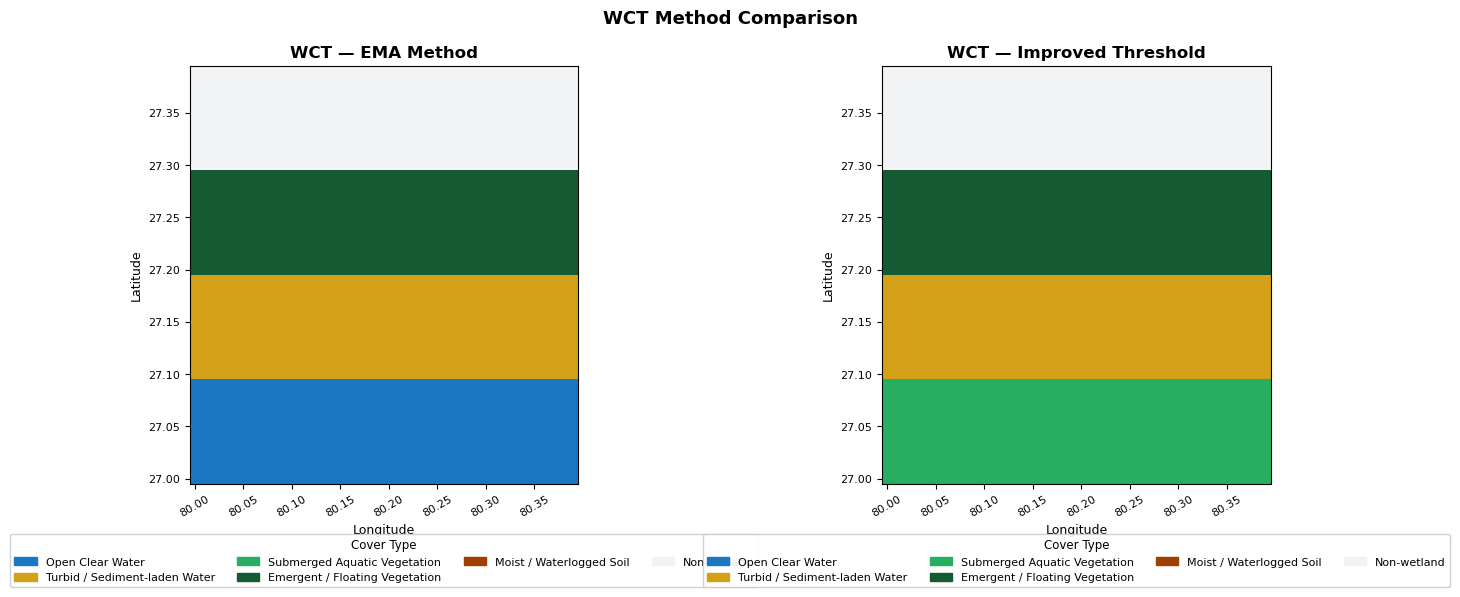

In [27]:
# ── Static fallback: WCT comparison side-by-side ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_wct(wct_ema, ax=axes[0], title='WCT — EMA Method',
         legend_loc='outside bottom')
plot_wct(wct_thr, ax=axes[1], title='WCT — Improved Threshold',
         legend_loc='outside bottom')
fig.suptitle('WCT Method Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_wct_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()

### 9b. MNDWI time slider

In [ ]:
mndwi_ts.hvplot.image(
    x='x', y='y', groupby='time',
    cmap='RdBu', clim=(-1, 1),
    colorbar=True, clabel='MNDWI',
    width=450, height=420,
    title='MNDWI — scrub through time',
    xlabel='Longitude', ylabel='Latitude',
)

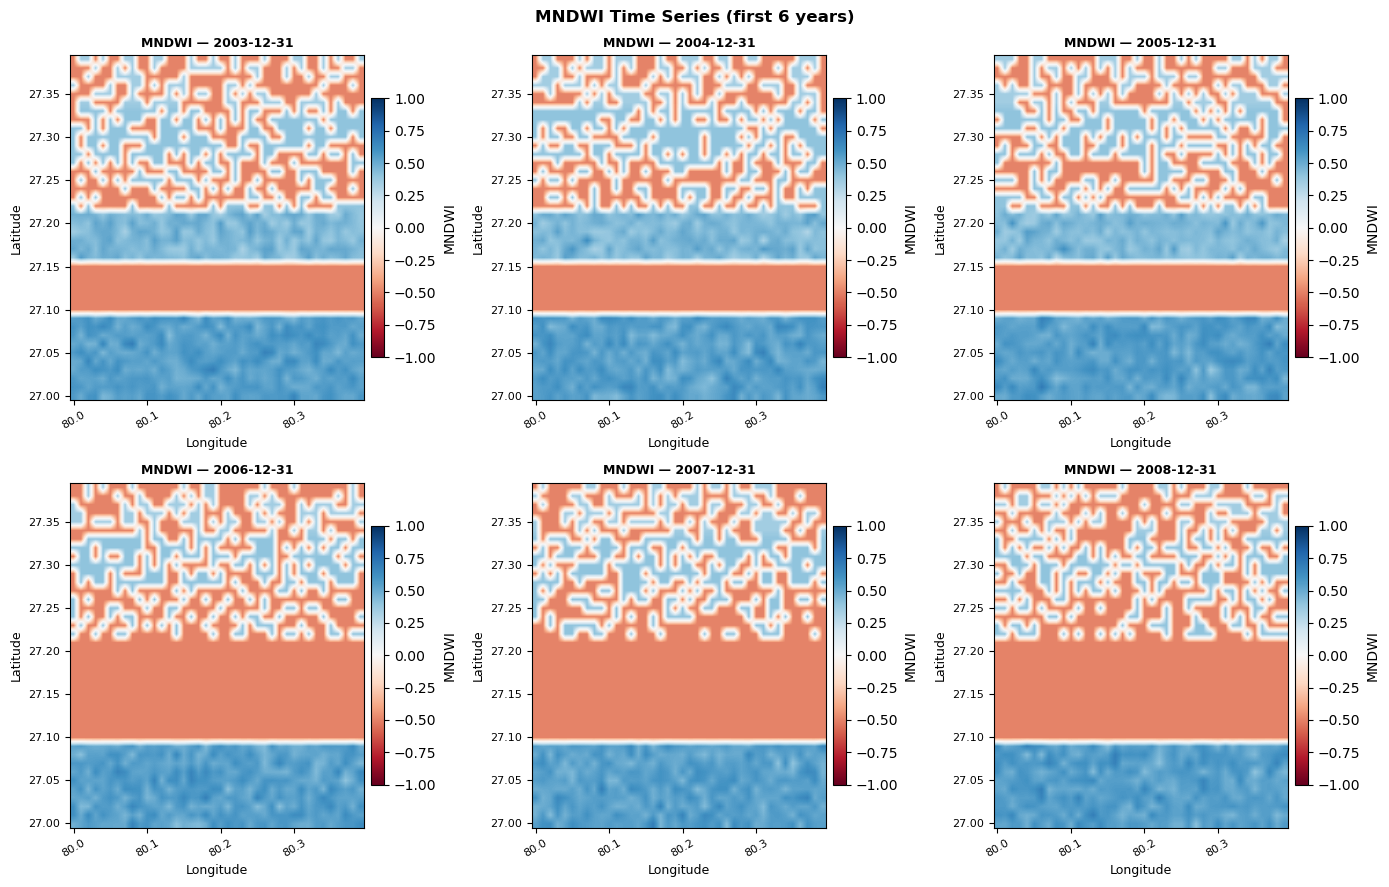

In [28]:
# ── Static fallback: MNDWI multi-panel (first 6 time steps) ────────────────
_n = min(6, len(mndwi_ts.time))
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for i, ax in enumerate(axes.flat[:_n]):
    plot_index(mndwi_ts, index_name='MNDWI', ax=ax, time_step=i,
               cmap='RdBu', vmin=-1, vmax=1)
    ax.set_title(f'MNDWI — {str(mndwi_ts.time.values[i])[:10]}',
                 fontsize=9, fontweight='bold')
plt.suptitle('MNDWI Time Series (first 6 years)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_mndwi_timeseries.png'),
            dpi=150, bbox_inches='tight')
plt.show()


### 9c. Chilika WCT time series — interactive stacked area

In [30]:
# Melt to long form for hvplot
chilika_long = chilika_df[wct_cols].reset_index().melt(
    id_vars='Date', var_name='Cover Type', value_name='Area (%)'
)

chilika_long.hvplot.bar(
    x='Date', y='Area (%)', by='Cover Type',
    stacked=True,
    color=wct_palette,
    width=900, height=350,
    title='Chilika Lake — Monthly WCT Composition (interactive)',
    ylabel='Area fraction (%)',
    xlabel='Date',
    legend='top_right',
)

:Bars   [Date,Cover Type]   (Area (%))

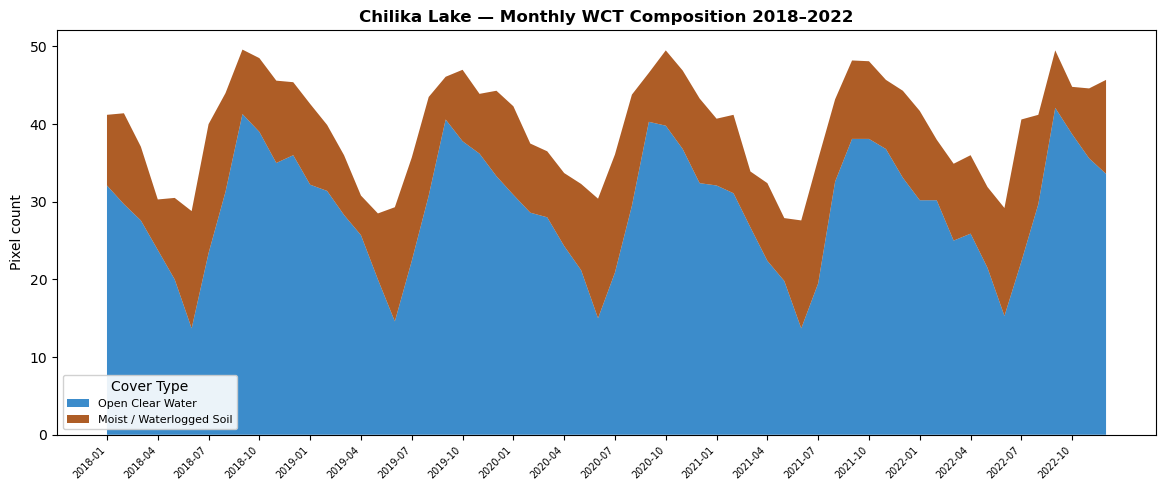

In [29]:
# ── Static fallback: Chilika WCT stacked area (matplotlib) ─────────────────
_wct_cols = [WCT_CLASSES[c] for c in sorted(WCT_CLASSES.keys()) if c != 0]
_wct_cols = [c for c in _wct_cols if c in chilika_df.columns]

_colors   = [WCT_COLORS[c] for c in sorted(WCT_CLASSES.keys())
             if c != 0 and WCT_CLASSES[c] in chilika_df.columns]

fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(
    range(len(chilika_df)),
    [chilika_df[col] for col in _wct_cols],
    labels=_wct_cols, colors=_colors, alpha=0.85
)
ax.set_xticks(range(0, len(chilika_df), 3))
ax.set_xticklabels(
    [str(chilika_df.index[i])[:7] for i in range(0, len(chilika_df), 3)],
    rotation=45, ha='right', fontsize=7
)
ax.set_ylabel('Pixel count', fontsize=10)
ax.set_title('Chilika Lake — Monthly WCT Composition 2018–2022', fontsize=12, fontweight='bold')
ax.legend(loc='lower left', 
          fontsize=8, framealpha=0.9, title='Cover Type')
fig.tight_layout(rect=[0, 0, 0.84, 1])
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_chilika_stacked.png'),
            dpi=150, bbox_inches='tight')
plt.show()


### 9d. Dynamics map + WCT Panel dashboard

In [30]:
wet_freq = compute_wet_frequency(mndwi_ts, mndwi_threshold=0.0)

map_dyn = dynamics.astype(float).hvplot.image(
    x='x', y='y', cmap=dyn_colors,
    clim=(min(dyn_codes)-0.5, max(dyn_codes)+0.5),
    colorbar=False, width=360, height=360,
    title='Dynamics', tools=['hover'],
    xlabel='Longitude', ylabel='Latitude',
)
map_ema_db = wct_ema.astype(float).hvplot.image(
    x='x', y='y', cmap=wct_colors,
    clim=(min(wct_codes)-0.5, max(wct_codes)+0.5),
    colorbar=False, width=360, height=360,
    title='WCT (EMA)', tools=['hover'],
    xlabel='Longitude', ylabel='',
)
map_freq = wet_freq.hvplot.image(
    x='x', y='y', cmap='Blues', clim=(0, 100),
    colorbar=True, clabel='%', width=360, height=360,
    title='Wet Frequency', tools=['hover'],
    xlabel='Longitude', ylabel='',
)

pn.Row(
    pn.Column('## WetlandMapper Dashboard', map_dyn),
    pn.Column('\n', map_ema_db),
    pn.Column('\n', map_freq),
)

Row
    [0] Column
        [0] Markdown(str)
        [1] HoloViews(Image, height=360, sizing_mode='fixed', width=360)
    [1] Column
        [0] Markdown(str)
        [1] HoloViews(Image, height=360, sizing_mode='fixed', width=360)
    [2] Column
        [0] Markdown(str)
        [1] HoloViews(Image, height=360, sizing_mode='fixed', width=360)

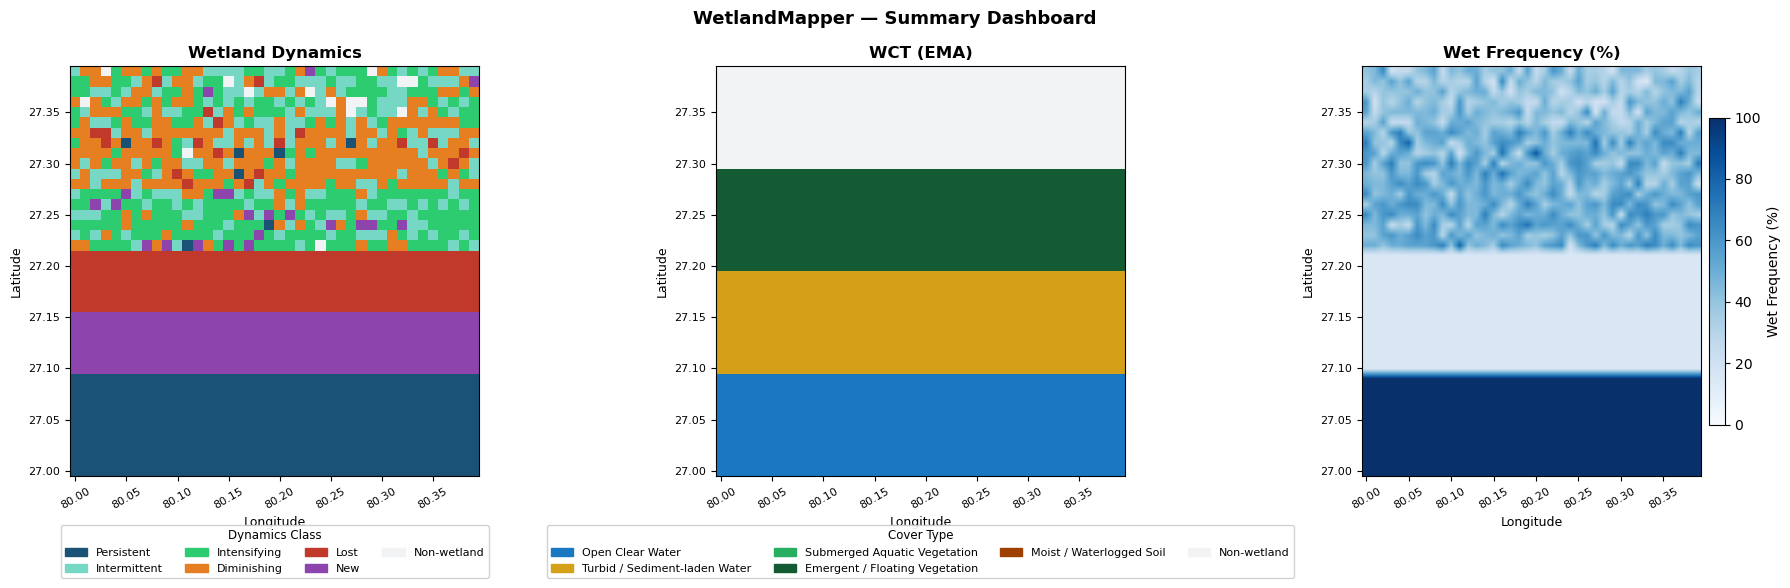

In [31]:
# ── Static fallback: 3-panel dashboard (dynamics, WCT, wet-freq) ───────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_dynamics(dynamics, ax=axes[0], title='Wetland Dynamics',
              legend_loc='outside bottom')
plot_wct(wct_ema, ax=axes[1], title='WCT (EMA)',
         legend_loc='outside bottom')
plot_wet_frequency(mndwi_ts, ax=axes[2])
plt.suptitle('WetlandMapper — Summary Dashboard', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_dashboard.png'),
            dpi=150, bbox_inches='tight')
plt.show()

### 9e. Pixel MNDWI time-series drill-down

In [32]:
sample_pixels = {
    'Zone A (Persistent)':   {'y': 27.05, 'x': 80.20},
    'Zone B (New)':          {'y': 27.13, 'x': 80.20},
    'Zone C (Lost)':         {'y': 27.19, 'x': 80.20},
    'Zone D (Intensifying)': {'y': 27.25, 'x': 80.20},
    'Zone E (Diminishing)':  {'y': 27.31, 'x': 80.20},
    'Zone F (Intermittent)': {'y': 27.37, 'x': 80.20},
}
plots = []
for label, coords in sample_pixels.items():
    ts = mndwi_ts.sel(y=coords['y'], x=coords['x'], method='nearest')
    ts_df = ts.to_dataframe(name='MNDWI').reset_index()[['time','MNDWI']]
    p = ts_df.hvplot.line(x='time', y='MNDWI', title=label,
                          color='steelblue', line_width=2,
                          ylim=(-1,1), width=380, height=200,
                          ylabel='MNDWI', xlabel='') \
      * hv.HLine(0).opts(color='red', line_dash='dashed', line_width=1)
    plots.append(p)

hv.Layout(plots).cols(2)

:Layout
   .Overlay.I   :Overlay
      .Curve.I :Curve   [time]   (MNDWI)
      .HLine.I :HLine   [x,y]
   .Overlay.II  :Overlay
      .Curve.I :Curve   [time]   (MNDWI)
      .HLine.I :HLine   [x,y]
   .Overlay.III :Overlay
      .Curve.I :Curve   [time]   (MNDWI)
      .HLine.I :HLine   [x,y]
   .Overlay.IV  :Overlay
      .Curve.I :Curve   [time]   (MNDWI)
      .HLine.I :HLine   [x,y]
   .Overlay.V   :Overlay
      .Curve.I :Curve   [time]   (MNDWI)
      .HLine.I :HLine   [x,y]
   .Overlay.VI  :Overlay
      .Curve.I :Curve   [time]   (MNDWI)
      .HLine.I :HLine   [x,y]

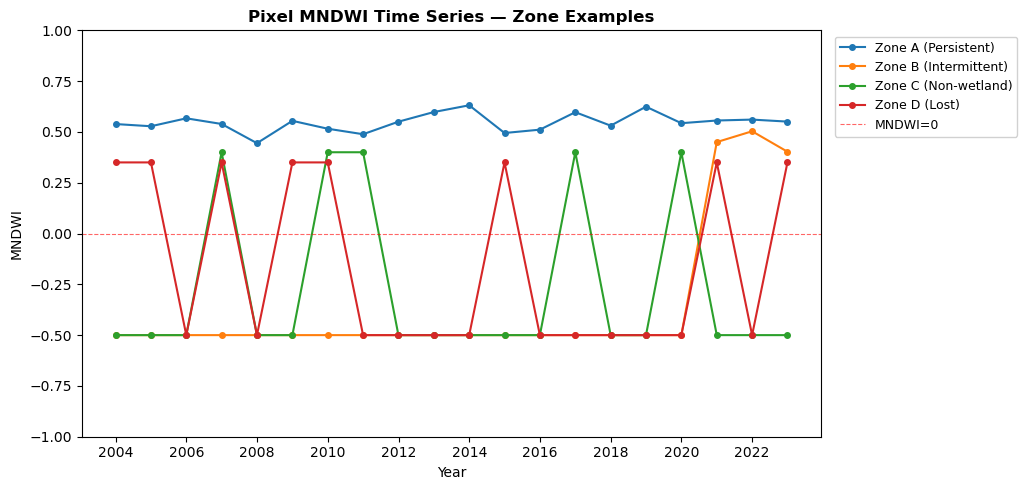

In [33]:
# ── Static fallback: pixel MNDWI time series ────────────────────────────────
_sample_pixels = {
    'Zone A (Persistent)':   {'y': 27.05, 'x': 80.20},
    'Zone B (Intermittent)': {'y': 27.15, 'x': 80.10},
    'Zone C (Non-wetland)':  {'y': 27.25, 'x': 80.30},
    'Zone D (Lost)':         {'y': 27.35, 'x': 80.25},
}
fig, ax = plt.subplots(figsize=(13, 5))
for label, coords in _sample_pixels.items():
    ts_px = mndwi_ts.sel(y=coords['y'], x=coords['x'], method='nearest').to_pandas()
    ax.plot(ts_px.index, ts_px.values, marker='o', markersize=4,
            linewidth=1.5, label=label)
ax.axhline(0, color='red', linewidth=0.8, linestyle='--', alpha=0.6, label='MNDWI=0')
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('MNDWI', fontsize=10)
ax.set_ylim(-1, 1)
ax.set_title('Pixel MNDWI Time Series — Zone Examples', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1),
          fontsize=9, framealpha=0.9)
fig.tight_layout(rect=[0, 0, 0.80, 1])
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_pixel_drilldown.png'),
            dpi=150, bbox_inches='tight')
plt.show()


---
## 10. Google Earth Engine Workflows

Two retrieval functions are available:

| Function | Mechanism | Best for |
|----------|-----------|----------|
| `fetch()` | `getDownloadURL` per composite, immediate numpy | Small AOIs, quick tests |
| `fetch_xee()` | xee + Dask lazy xarray | Large AOIs, long time series |

Both functions:
- Compute indices **server-side** on GEE using `image.normalizedDifference()`
- Accept a `temporal_aggregation` parameter for server-side compositing
- Fix the Sentinel-2 `CLOUDY_PIXEL_PERCENTAGE` property

**`fetch_xee` spatial gridding fix:**  
xee requires a bounding-box geometry to produce a proper spatial grid.  An
arbitrary polygon causes xee to sample only at the centroid (one pixel).  The
bounding box is extracted automatically inside `fetch_xee()` via
`ee_geom.bounds()`, so you can still pass any polygon as `aoi`.

### Band assignments used on GEE

| Index | Formula | Landsat 8/9 C02 L2 bands | Sentinel-2 SR bands |
|-------|---------|--------------------------|---------------------|
| MNDWI | (Green − SWIR1) / sum | SR_B3, SR_B6 | B3, B11 |
| NDVI  | (NIR − Red) / sum     | SR_B5, SR_B4 | B8, B4  |
| NDTI  | (Red − Green) / sum   | SR_B4, SR_B3 | B4, B3  |

Landsat DN → reflectance: `DN × 0.0000275 + (−0.2)`  
Sentinel-2 DN → reflectance: `DN ÷ 10000`


In [37]:
# ─── Initialise GEE ───────────────────────────────────────────────────────────
# import ee
# ee.Authenticate()   # Run once; credentials cached
# ee.Initialize(project='drylands-aberuni')

<xarray.DataArray 'MNDWI' (time: 40, y: 483, x: 613)> Size: 95MB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
..

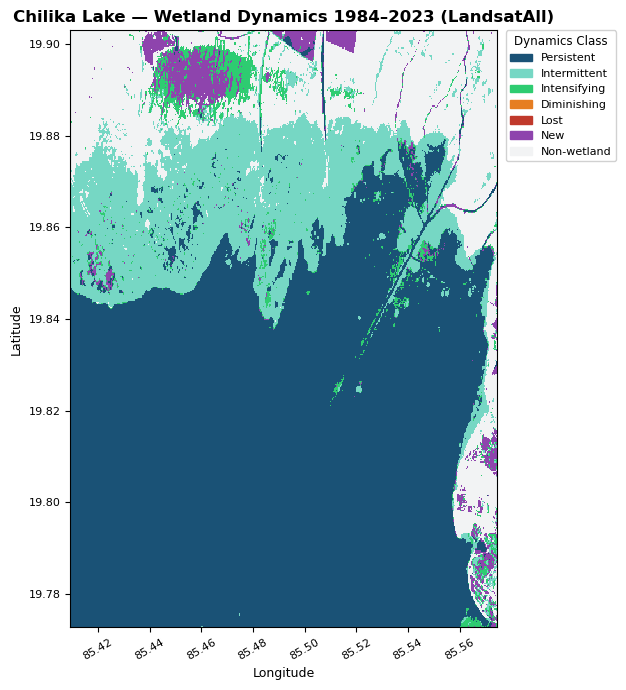

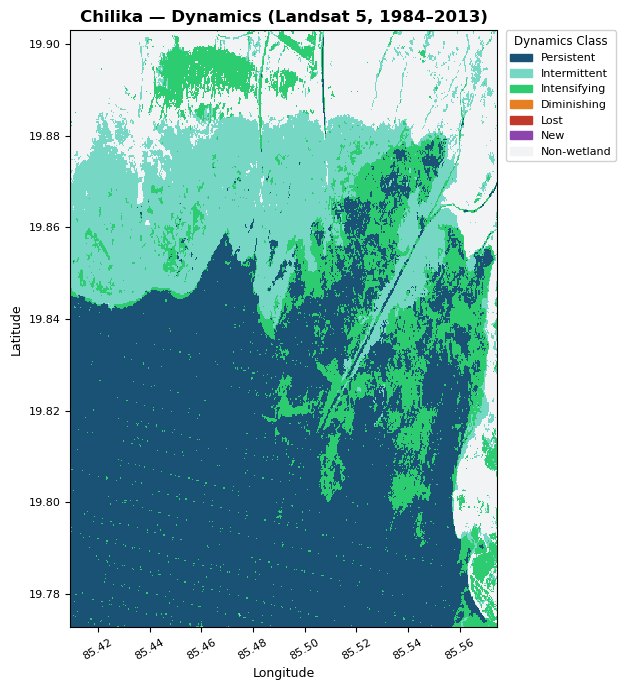

['1999-07-01T00:00:00.000000' '2000-07-01T00:00:00.000000'
 '2001-07-01T00:00:00.000000' '2002-07-01T00:00:00.000000'
 '2003-07-01T00:00:00.000000' '2004-07-01T00:00:00.000000'
 '2005-07-01T00:00:00.000000' '2006-07-01T00:00:00.000000'
 '2007-07-01T00:00:00.000000' '2008-07-01T00:00:00.000000'
 '2009-07-01T00:00:00.000000' '2010-07-01T00:00:00.000000'
 '2011-07-01T00:00:00.000000' '2012-07-01T00:00:00.000000'
 '2013-07-01T00:00:00.000000' '2014-07-01T00:00:00.000000'
 '2015-07-01T00:00:00.000000' '2016-07-01T00:00:00.000000'
 '2017-07-01T00:00:00.000000' '2018-07-01T00:00:00.000000'
 '2019-07-01T00:00:00.000000' '2020-07-01T00:00:00.000000'
 '2021-07-01T00:00:00.000000' '2022-07-01T00:00:00.000000']


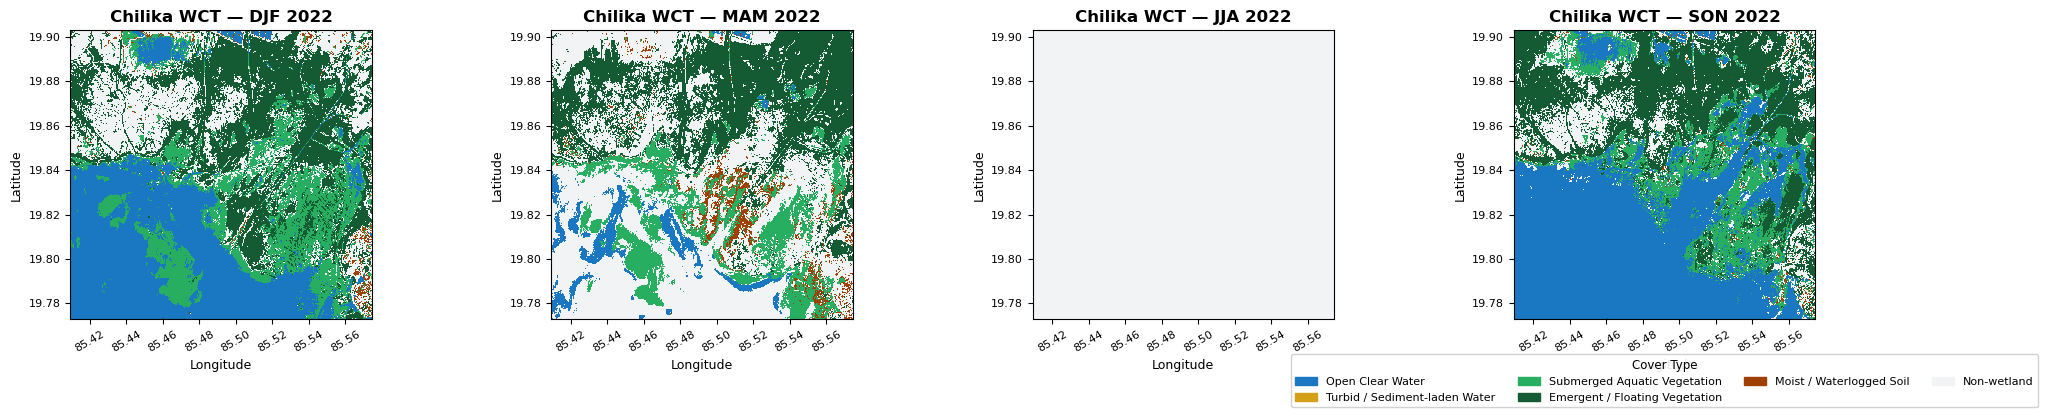

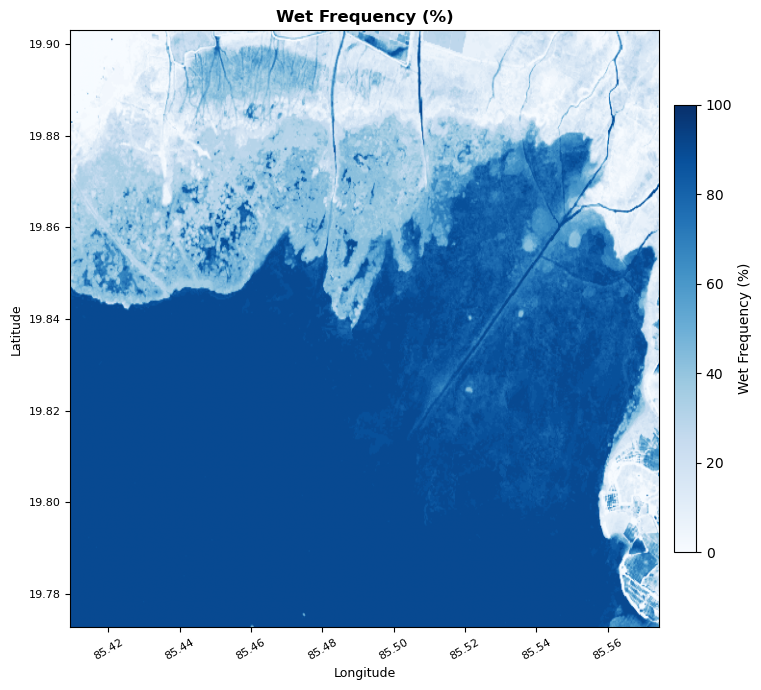

In [34]:
# ═══════════════════════════════════════════════════════════════════════
# fetch() — immediate download, all Landsat missions
#
# Supported sensors:
#   'Landsat4'   — TM  1982–1993
#   'Landsat5'   — TM  1984–2013
#   'Landsat7'   — ETM+ 1999–2022 (SLC failure 2003-05-31)
#   'Landsat8'   — OLI  2013–present   [default]
#   'Landsat9'   — OLI-2 2021–present
#   'LandsatAll' — merges all available missions for the date range
#   'Sentinel2'  — MSI  2015–present
#
# use_slc_off=False (default) excludes Landsat 7 post-SLC-failure images.
# Set True to include the 2003–2013 record (striped data, ~22% gaps/scene).
# ═══════════════════════════════════════════════════════════════════════

# Requires a GEE account (earthengine authenticate)

from wetlandmapper.gee import fetch
#
# chilika_aoi = {
#     'type': 'Polygon',
#     'coordinates': [[[85.05,19.65],[85.55,19.65],
#                       [85.55,19.95],[85.05,19.95],[85.05,19.65]]]
# }
#
chilika_aoi = 'chilika_north/Chilika_north.shp' # A small part of Chilika wetland, with freshwater input region (NE)

# ── 1. Long-record dynamics with ALL Landsat missions (1984–2023) ──────────
# 'LandsatAll' automatically merges L4/5/7/8/9 and harmonises band names
mndwi_gee = fetch(
    chilika_aoi, start='1984-01-01', end='2023-12-31',
    sensor='LandsatAll',
    temporal_aggregation='annual',   # one median composite per year
    use_slc_off=False,               # exclude L7 post-SLC-failure
    max_cloud_cover=20,
)
print(mndwi_gee)   # DataArray (time=40, y=..., x=...)

dynamics_gee = classify_dynamics(mndwi_gee, nYear=3,
                                  thresholdWet=25, thresholdPersis=75)

fig, ax = plot_dynamics(
    dynamics_gee,
    title='Chilika Lake — Wetland Dynamics 1984–2023 (LandsatAll)',
    legend_loc='outside right',
    savepath=os.path.join(OUTPUT_DIR, 'chilika_dynamics_landsatall.png'),
)
plt.show()

# ── 2. Landsat 5 era (1984–2013) dynamics ──────────────────────────────────
mndwi_l5 = fetch(
    chilika_aoi, start='1984-01-01', end='2013-06-05',
    sensor='Landsat5',
    temporal_aggregation='annual',
)
dynamics_l5 = classify_dynamics(mndwi_l5, nYear=3)
fig, ax = plot_dynamics(
    dynamics_l5, title='Chilika — Dynamics (Landsat 5, 1984–2013)',
    savepath=os.path.join(OUTPUT_DIR, 'chilika_dynamics_l5.png'),
)
plt.show()

# ── 3. Landsat 7 SLC-on only (1999–2003) ───────────────────────────────────
mndwi_l7 = fetch(
    chilika_aoi, start='1999-04-15', end='2022-04-06',
    sensor='Landsat7',
    use_slc_off=False,               # only 1999-2003 SLC-on data used
    temporal_aggregation='annual',
)
print(mndwi_l7.time.values)          # will only cover 1999–2002

# ── 4. Seasonal WCT composites from Landsat 8 ──────────────────────────────
indices_seasonal = fetch(
    chilika_aoi, start='2022-01-01', end='2022-12-31',
    sensor='Landsat8',
    index=['MNDWI','NDVI','NDTI'],
    temporal_aggregation='seasonal',
)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for t, (ax, sname) in enumerate(zip(axes, ['DJF','MAM','JJA','SON'])):
    wct_s = classify_wct_ema(indices_seasonal.isel(time=t))
    plot_wct(wct_s['wetland_cover_type'], ax=ax,
             title=f'Chilika WCT — {sname} 2022',
             legend_loc='outside bottom',
             add_colorbar=(t == 3))
plt.savefig(os.path.join(OUTPUT_DIR, 'chilika_wct_seasonal_2022.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# ── 5. Wet frequency map ───────────────────────────────────────────────────
fig, ax = plot_wet_frequency(
    mndwi_gee,
    savepath=os.path.join(OUTPUT_DIR, 'chilika_wet_frequency.png'),
)
plt.show()

In [35]:
# ═══════════════════════════════════════════════════════════════════════
# fetch_xee() — lazy Dask-backed xarray
# ═══════════════════════════════════════════════════════════════════════

from wetlandmapper.gee import fetch_xee
#
# chilika_aoi = {
#     'type': 'Polygon',
#     'coordinates': [[[85.05,19.65],[85.55,19.65],
#                       [85.55,19.95],[85.05,19.95],[85.05,19.65]]]
# }
#
# ── Lazy annual MNDWI — all Landsat missions ───────────────────────────────
mndwi_lazy = fetch_xee(
    chilika_aoi, start='1984-01-01', end='2023-12-31',
    sensor='LandsatAll',
    temporal_aggregation='annual',
    use_slc_off=False,
    chunks={'time': 1, 'lat': 512, 'lon': 512},
)
# Nothing downloaded yet. xee uses lat/lon; rename to y/x for wetlandmapper
mndwi_lazy = mndwi_lazy.rename({'lat': 'y', 'lon': 'x'}).sortby("y", ascending=False).transpose("time", "y", "x")
print('Lazy shape:', dict(mndwi_lazy.sizes))

#── Seasonal WCT via xee ───────────────────────────────────────────────────
indices_lazy = fetch_xee(
    chilika_aoi, start='2022-01-01', end='2022-12-31',
    sensor='Landsat8',
    index=['MNDWI','NDVI','NDTI'],
    temporal_aggregation='seasonal',
    chunks={'time': 1, 'lat': 512, 'lon': 512},
).rename({'lat': 'y', 'lon': 'x'}).sortby("y", ascending=False).transpose("time", "y", "x")




Lazy shape: {'time': 40, 'y': 482, 'x': 612}


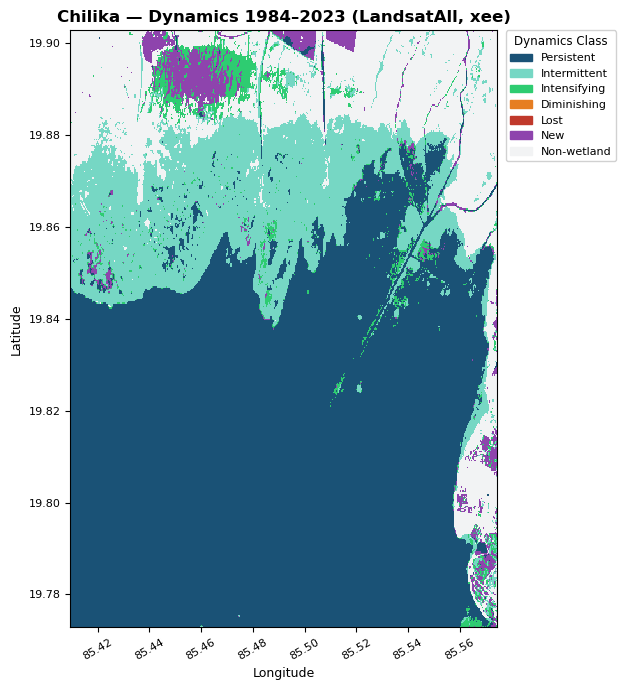

In [36]:
# Download & classify
mndwi_xee = mndwi_lazy.compute()
dynamics_xee = classify_dynamics(mndwi_xee, nYear=3,
                                  thresholdWet=25, thresholdPersis=75)
# Static plot 
fig, ax = plot_dynamics(
    dynamics_xee,
    title='Chilika — Dynamics 1984–2023 (LandsatAll, xee)',
    legend_loc='outside right',
    savepath=os.path.join(OUTPUT_DIR, 'chilika_dynamics_xee.png'),
)
plt.show()

# # Interactive hvplot
# try:
#     import hvplot.xarray  # noqa
#     dynamics_xee.astype(float).hvplot.image(
#         x='x', y='y',
#         title='Chilika Dynamics — xee (LandsatAll 1984–2023)',
#         width=600, height=500,
#     )
# except ImportError:
#     print('hvplot not installed; using static plot above.')

In [ ]:
indices_comp = indices_lazy.compute()

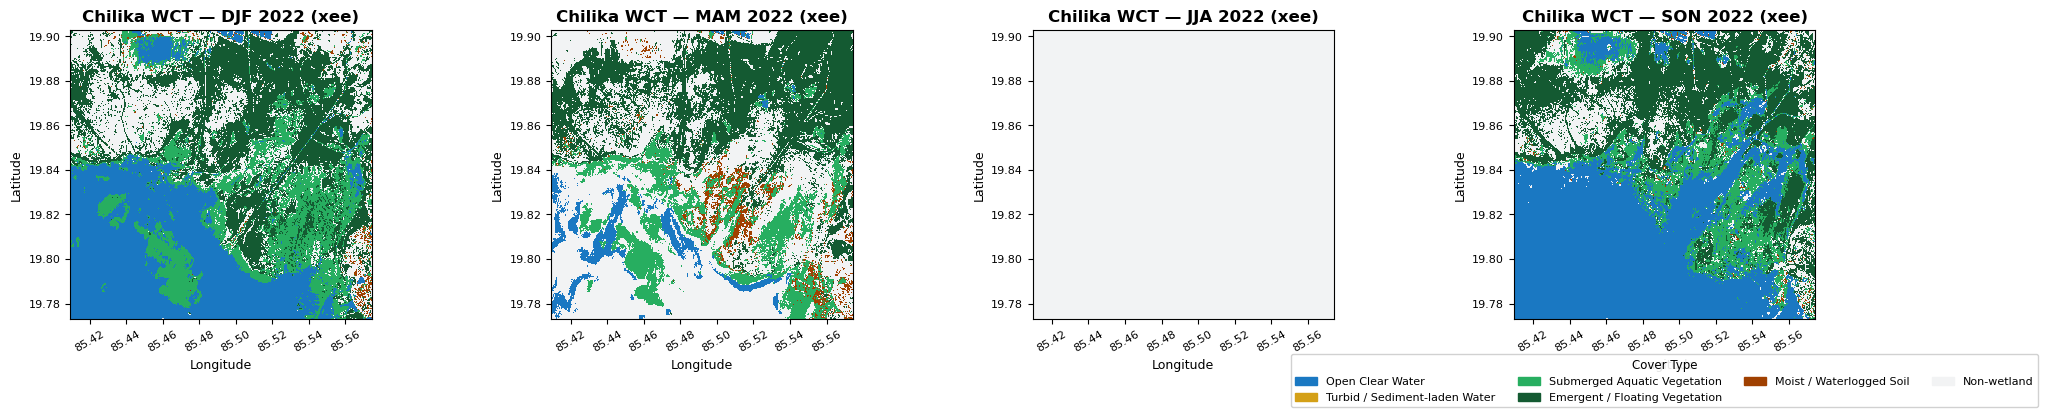

In [37]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for t, (ax, sname) in enumerate(zip(axes, ['DJF', 'MAM', 'JJA', 'SON'])):
    wct_ds = classify_wct_ema(indices_comp.isel(time=t))
    plot_wct(wct_ds['wetland_cover_type'], ax=ax,
             title=f'Chilika WCT — {sname} 2022 (xee)',
             add_colorbar=(t == 3), legend_loc='outside bottom')
plt.savefig(os.path.join(OUTPUT_DIR, 'chilika_wct_seasonal_xee.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [38]:
indices_comp

<xarray.Dataset> Size: 14MB
Dimensions:  (time: 4, x: 612, y: 482)
Coordinates:
  * time     (time) datetime64[ns] 32B 2022-01-15 2022-04-15 ... 2022-10-15
  * x        (x) float64 5kB 85.41 85.41 85.41 85.41 ... 85.57 85.57 85.57 85.57
  * y        (y) float64 4kB 19.9 19.9 19.9 19.9 ... 19.77 19.77 19.77 19.77
Data variables:
    MNDWI    (time, y, x) float32 5MB -0.4507 -0.4333 -0.4519 ... 0.3464 0.3273
    NDVI     (time, y, x) float32 5MB 0.3708 0.3906 0.5967 ... 0.4812 0.4384
    NDTI     (time, y, x) float32 5MB 0.06191 0.06527 ... -0.1647 -0.1629
Attributes:
    crs:      EPSG:4326

---
## 11. Saving Outputs

In [50]:
# ── Section 11: Saving Outputs ───────────────────────────────────────────────
#
# Choose your preferred output format:
#   'tiff'  → 2-D arrays saved as GeoTIFF; time-series saved as one GeoTIFF
#             per time step, named  <name>_YYYY-MM-DD.tif
#   'netcdf' → everything (2-D and time-series) saved as NetCDF (.nc)
#
OUTPUT_FORMAT = 'tiff'   # ← change to 'netcdf' if preferred

import rioxarray  # noqa — needed for .rio accessor

def save_da(da, name, fmt=OUTPUT_FORMAT, out_dir=OUTPUT_DIR, dtype='float32'):
    """
    Save a DataArray (or single-variable Dataset) to disk.

    Parameters
    ----------
    da     : xr.DataArray or xr.Dataset (single variable)
    name   : base filename (no extension)
    fmt    : 'tiff' or 'netcdf'
    out_dir: output directory
    dtype  : dtype for GeoTIFF (e.g. 'float32', 'int8')
    """
    import xarray as xr
    os.makedirs(out_dir, exist_ok=True)

    # Unwrap single-variable Dataset
    if isinstance(da, xr.Dataset):
        if len(da.data_vars) == 1:
            da = da[list(da.data_vars)[0]]
        else:
            path = os.path.join(out_dir, f'{name}.nc')
            da.to_netcdf(path)
            print(f'  Saved Dataset (multi-var) → {path}')
            return

    def _write_tiff(arr2d, fpath):
        if arr2d.rio.crs is None:
            arr2d = arr2d.rio.write_crs('EPSG:4326')
        if arr2d.rio.nodata is None:
            # Pick a nodata value that fits the target dtype
            nodata = -128 if dtype in ('int8',) else (
                -32768 if dtype in ('int16',) else -9999
            )
            arr2d = arr2d.rio.write_nodata(nodata)
        arr2d.rio.to_raster(fpath, dtype=dtype)

    if fmt == 'netcdf':
        path = os.path.join(out_dir, f'{name}.nc')
        da.to_netcdf(path)
        n = len(da.time) if 'time' in da.dims else '2-D'
        print(f'  Saved ({n} steps) → {path}')

    elif fmt == 'tiff':
        if 'time' not in da.dims:
            # Single 2-D raster → one GeoTIFF
            path = os.path.join(out_dir, f'{name}.tif')
            _write_tiff(da, path)
            print(f'  Saved 2-D raster → {path}')
        else:
            # Time-series → one dated GeoTIFF per time step
            for t in da.time.values:
                ts = str(t)[:10]           # 'YYYY-MM-DD'
                path = os.path.join(out_dir, f'{name}_{ts}.tif')
                _write_tiff(da.sel(time=t), path)
            print(f'  Saved {len(da.time)} GeoTIFFs → {out_dir}/{name}_*.tif')

    else:
        raise ValueError(f"OUTPUT_FORMAT must be 'tiff' or 'netcdf', got {fmt!r}")



In [52]:
# ── Save synthetic workflow outputs ─────────────────────────────────────────

# Dynamics map (2-D int8)
save_da(dynamics, 'dynamics_20yr', dtype='int8')

# WCT EMA — class map and combination-code map (both 2-D)
save_da(wct_ema,   'wct_ema',          dtype='int8')
save_da(combo_map, 'wct_ema_combo',    dtype='int8')

# WCT improved threshold map (2-D int8)
save_da(wct_thr,   'wct_threshold',    dtype='int8')

# Wet frequency map (2-D float)
save_da(wet_freq,  'wet_frequency')

# MNDWI time series — one file (NetCDF) or one GeoTIFF per year
save_da(mndwi_ts,  'mndwi_timeseries')

# ── Save Chilika WCT synthetic time-series as CSV ───────────────────────────
csv_path = os.path.join(OUTPUT_DIR, 'chilika_wct_timeseries.csv')
chilika_df.to_csv(csv_path)
print(f'  Saved CSV  → {csv_path}')

# ── Save static figures ──────────────────────────────────────────────────────
_plots = [
    (dynamics, plot_dynamics, dict(title='Wetland Dynamics 2003-2022'), 'fig_dynamics.png'),
    (wct_ema,  plot_wct,      dict(title='WCT - EMA Method'),           'fig_wct_ema.png'),
    (wct_thr,  plot_wct,      dict(title='WCT - Threshold Method'),     'fig_wct_threshold.png'),
]
for da, fn, kwargs, fname in _plots:
    out_path = os.path.join(OUTPUT_DIR, fname)
    fig, ax = fn(da, **kwargs, legend_loc='outside right', savepath=out_path, dpi=150)
    plt.close(fig)
    print(f'  Saved figure → {out_path}')

fig, ax = plot_wet_frequency(
    mndwi_ts, savepath=os.path.join(OUTPUT_DIR, 'fig_wet_frequency.png'), dpi=150
)
plt.close(fig)


  Saved 2-D raster → ./wetlandmapper_outputs/dynamics_20yr.tif
  Saved 2-D raster → ./wetlandmapper_outputs/wct_ema.tif
  Saved 2-D raster → ./wetlandmapper_outputs/wct_ema_combo.tif
  Saved 2-D raster → ./wetlandmapper_outputs/wct_threshold.tif
  Saved 2-D raster → ./wetlandmapper_outputs/wet_frequency.tif
  Saved 20 GeoTIFFs → ./wetlandmapper_outputs/mndwi_timeseries_*.tif
  Saved CSV  → ./wetlandmapper_outputs/chilika_wct_timeseries.csv
  Saved figure → ./wetlandmapper_outputs/fig_dynamics.png
  Saved figure → ./wetlandmapper_outputs/fig_wct_ema.png
  Saved figure → ./wetlandmapper_outputs/fig_wct_threshold.png


In [54]:
# ── GEE / xee outputs  ──────────────────
save_da(mndwi_gee,    'chilika_mndwi_landsatall', fmt= 'netcdf')   # time-series
save_da(dynamics_gee, 'chilika_dynamics_gee', dtype='int8')
wct_gee_ds = classify_wct_ema(indices_seasonal.isel(time=0))
save_da(wct_gee_ds['wetland_cover_type'], 'chilika_wct_ema_djf', dtype='int8')
save_da(wct_gee_ds['combination_code'],   'chilika_wct_combo_djf', dtype='int16')

print(f'\nAll outputs saved to: {(OUTPUT_DIR)}')

  Saved (40 steps) → ./wetlandmapper_outputs/chilika_mndwi_landsatall.nc
  Saved 2-D raster → ./wetlandmapper_outputs/chilika_dynamics_gee.tif
  Saved 2-D raster → ./wetlandmapper_outputs/chilika_wct_ema_djf.tif
  Saved 2-D raster → ./wetlandmapper_outputs/chilika_wct_combo_djf.tif

All outputs saved to: ./wetlandmapper_outputs


---
## Summary

| Workflow | Key function | Input | Output |
|----------|-------------|-------|--------|
| Dynamics | `classify_dynamics()` | MNDWI time series | 6 temporal classes |
| WCT (EMA original) | `classify_wct_ema()` | MNDWI + NDVI + NDTI composite | 5 biophysical classes (quartile bins) |
| WCT (improved) | `classify_wct()` | MNDWI + NDVI + NDTI composite | 5 biophysical classes (free thresholds) |
| GEE (immediate) | `gee.fetch()` | AOI + date range | xarray, data downloaded at call |
| GEE (lazy) | `gee.fetch_xee()` | AOI + date range | Dask-backed xarray, download on `.compute()` |

### References
- Singh, M., & Sinha, R. (2022). *Remote Sensing Letters*, 13(1), 1–13. https://doi.org/10.1080/2150704X.2021.1980919
- Singh, M., Allaka, S., et al. (2022). *Environmental Monitoring and Assessment*, 194(12), 878. https://doi.org/10.1007/s10661-022-10541-7